In [2]:
import json

def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            return data
    except FileNotFoundError:
        print("Файл не найден")
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате JSON: {e}")


j = load_json("/mnt/external_usb_hdd/6YL/Datasets/3RScan/files/3RScan_small.json")


In [3]:
import os
import json
import torch
import faiss
import logging
import numpy as np
from glob import glob
from tqdm import tqdm
from PIL import Image
from os.path import join
import torch.utils.data as data
from scipy.spatial import KDTree
import torchvision.transforms as transforms
from torch.utils.data.dataset import Subset
from sklearn.neighbors import NearestNeighbors
from torch.utils.data.dataloader import DataLoader

from scipy.spatial.distance import pdist
import math

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def path_to_pil_img(path):
    return Image.open(path).convert("RGB")


def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            return data
    except FileNotFoundError:
        print("Файл не найден")
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате JSON: {e}")


def collate_fn(batch):
    """Creates mini-batch tensors from the list of tuples (images, 
        triplets_local_indexes, triplets_global_indexes).
        triplets_local_indexes are the indexes referring to each triplet within images.
        triplets_global_indexes are the global indexes of each image.
    Args:
        batch: list of tuple (images, triplets_local_indexes, triplets_global_indexes).
            considering each query to have 10 negatives (negs_num_per_query=10):
            - images: torch tensor of shape (12, 3, h, w).
            - triplets_local_indexes: torch tensor of shape (10, 3).
            - triplets_global_indexes: torch tensor of shape (12).
    Returns:
        images: torch tensor of shape (batch_size*12, 3, h, w).
        triplets_local_indexes: torch tensor of shape (batch_size*10, 3).
        triplets_global_indexes: torch tensor of shape (batch_size, 12).
    """
    images                  = torch.cat([e[0] for e in batch])
    triplets_local_indexes  = torch.cat([e[1][None] for e in batch])
    triplets_global_indexes = torch.cat([e[2][None] for e in batch])
    for i, (local_indexes, global_indexes) in enumerate(zip(triplets_local_indexes, triplets_global_indexes)):
        local_indexes += len(global_indexes) * i  # Increment local indexes by offset (len(global_indexes) is 12)
    return images, torch.cat(tuple(triplets_local_indexes)), triplets_global_indexes


#def extract_sequence_id(path):



class PCADataset(data.Dataset):
    def __init__(self, args, datasets_folder="dataset", dataset_folder="pitts30k/images/train"):
        dataset_folder_full_path = join(datasets_folder, dataset_folder)
        if not os.path.exists(dataset_folder_full_path) :
            raise FileNotFoundError(f"Folder {dataset_folder_full_path} does not exist")
        self.images_paths = sorted(glob(join(dataset_folder_full_path, "**", "*.jpg"), recursive=True))
    def __getitem__(self, index):
        return base_transform(path_to_pil_img(self.images_paths[index]))
    def __len__(self):
        return len(self.images_paths)

def make_item(img_path, graph_path=None, scene=None, pose=None):
    return {"img": img_path, "graph": graph_path, "scene": scene, "pose": pose}

class BaseDataset(data.Dataset):
    """
    Dataset with images from database and queries, used for inference (testing and building cache).
    Refactored: вынесены вспомогательные методы для поддержки нескольких модальностей.
    При несоответствии длин модальностей: печатаем информацию и ПРОПУСКАЕМ сцену.
    """
    def __init__(self, args, datasets_folder="datasets", dataset_name="3RScan", split="train"):
        super().__init__()
        self.args = args
        self.modalites = getattr(args, 'modalites', ['image', 'graph', 'pose'])
        self.dataset_name = dataset_name
        self.dataset_folder = join(datasets_folder, dataset_name)
        if not os.path.exists(self.dataset_folder):
            raise FileNotFoundError(f"Folder {self.dataset_folder} does not exist")

        # контейнеры для элементов (items)
        self.database_items = []
        self.queries_items = []

        meta_data = join(self.dataset_folder, 'files')
        scene_data_path = join(meta_data, '3RScan_small.json')
        scene_data = load_json(scene_data_path) or []


        # ---- Построение словарей соответствий ----
        self.transforms = {}          # scan_name -> 4x4 matrix to reference
        self.scan_to_ref = {}          # scan_name -> reference_name
        self.ref_to_scans = {}         # reference_name -> list of scan_names

        for entry in scene_data:
            ref = entry['reference']
            self.scan_to_ref[ref] = ref
            self.ref_to_scans[ref] = []
            self.transforms[ref] = np.eye(4)  # reference сам в себе

            for scan in entry.get('scans', []):
                scan_name = scan['reference']
                self.scan_to_ref[scan_name] = ref
                self.ref_to_scans[ref].append(scan_name)
                # Матрица из JSON (список 16 чисел) -> 4x4
                if 'transform' in scan:
                    mat = np.array(scan['transform']).reshape(4, 4)
                else:
                    mat = np.eye(4)
                self.transforms[scan_name] = mat
        print("SCAN LEN", len(self.scan_to_ref))

        # загружаем метаданные конкретного датасета (3RScan)
        if dataset_name == "3RScan":
            if split == 'train':
                split_scans_path = join(meta_data, "train_scans_small.txt")
            elif split == 'test':
                split_scans_path = join(meta_data, "test_resplit_scans_small.txt")
            else:
                split_scans_path = join(meta_data, f"{split}_scans.txt")

            with open(split_scans_path, 'r', encoding='utf-8') as f:
                scene_names = [l.strip() for l in f if l.strip()]
            
            print(len(scene_names))
            # обработка каждого сцены
            for scene_name in scene_names:
                # собираем элементы для database (самой сцены)

                is_ref = (scene_name in self.scan_to_ref and self.scan_to_ref[scene_name] == scene_name)
                if is_ref:
                    db_items = self._build_items_for_scene(scene_name)
                    if db_items:
                        self.database_items.extend(db_items)
                    else:
                        print(f"[SKIP] Пропускаю scene '{scene_name}' для database (несоответствие модальностей).")
                else:
                    print(f"ОШИБКА. {scene_name} не является reference сценой")
                    continue
                
                for query_scene in self.ref_to_scans[scene_name]:
                    # Добавляем в queries
                    q_items = self._build_items_for_scene(query_scene)
                    if q_items:
                        self.queries_items.extend(q_items)
                    else:
                        print(f"[SKIP] Пропускаю scene '{query_scene}' для query (несоответствие модальностей).")

                """
                db_items = self._build_items_for_scene(scene_name)
                if not db_items:
                    print(f"[SKIP] Пропускаю scene '{scene_name}' для database (несоответствие модальностей).")
                else:
                    self.database_items.extend(db_items)

                # ищем запись в scene_data и собираем элементы для связанных scan-queries
                for scene_entry in scene_data:
                    if scene_entry.get('reference') != scene_name:
                        continue
                    scans_queries = scene_entry.get('scans', [])
                    for scene_queries_data in scans_queries:
                        scene_queries_name = scene_queries_data.get('reference')
                        if not scene_queries_name:
                            continue
                        q_items = self._build_items_for_scene(scene_queries_name)
                        if not q_items:
                            print(f"[SKIP] Пропускаю scene '{scene_queries_name}' для queries (несоответствие модальностей).")
                        else:
                            self.queries_items.extend(q_items)
                """

        self.items = self.database_items + self.queries_items
        
        self.soft_positives_per_query = self._build_soft_positives(radius=1)  # радиус в метрах

    # ----------------- вспомогательные методы -----------------

    def _list_scene_files(self, scene_name):
        """
        Вернёт словарь списков путей для запрошенных модальностей.
        keys: 'images', 'poses', 'graphs' (в зависимости от modalites)
        """
        files = {}
        scene_graph_path = join(self.dataset_folder, "Splited_graphs", scene_name)
        scene_image_path = join(self.dataset_folder, 'scenes', scene_name, 'sequence')

        if 'image' in self.modalites:
            files['images'] = sorted([
                p for p in glob(join(scene_image_path, "**", "frame-*.color.jpg"), recursive=True)
                if '.rendered.' not in p
            ])
        if 'pose' in self.modalites:
            files['poses'] = sorted(glob(join(scene_image_path, "**", "*.pose.txt"), recursive=True))
        if 'graph' in self.modalites:
            files['graphs'] = sorted(glob(join(scene_graph_path, "**", "*.pt"), recursive=True))

        return files

    def _basename_key(self, path):
        """
        Попытка получить "ключ" из имени файла — например 'frame-0001' из 'frame-0001.color.jpg',
        'frame-0001' из 'frame-0001.pose.txt' или 'frame-0001' из 'frame-0001.pt'.
        """
        if path is None:
            return None
        name = os.path.basename(path)
        # Берём часть до первого "." — для твоего формата это даёт 'frame-XXXX'
        return name.split('.')[0]

    def _validate_scene_alignment(self, files, scene_name=None):
        """
        Проверка согласованности длин списков.
        Если есть рассинхронизация — печатаем подробную информацию и возвращаем False (чтобы сцена была пропущена).
        Возвращает True, если всё согласовано.
        """
        def _sample_names(lst, max_show=6):
            if not lst:
                return []
            if len(lst) <= max_show:
                return [os.path.basename(p) for p in lst]
            k = max_show // 2
            head = [os.path.basename(p) for p in lst[:k]]
            tail = [os.path.basename(p) for p in lst[-(max_show-k):]]
            return head + ["..."] + tail

        # собираем модальности, которые присутствуют
        present = [(k, len(files.get(k, []))) for k in ('images', 'poses', 'graphs') if k in files]
        if len(present) <= 1:
            return True  # нечего сравнивать — считаем OK

        # выберем опорную модальность: images если есть, иначе первая
        names_lengths = {name: ln for name, ln in present}
        base_name = 'images' if 'images' in names_lengths else present[0][0]
        base_len = names_lengths[base_name]

        # найдём несовпадения
        mismatches = [(name, ln) for name, ln in present if ln != base_len]
        if not mismatches:
            return True

        # Формируем подробный вывод
        scene_info = f" (scene_id='{scene_name}')" if scene_name is not None else ""
        lines = [f"[MODALITY MISMATCH] Несовпадение длин файлов для сцены{scene_info}:"]
        lines.append(f"  Опорная модальность: '{base_name}' -> {base_len} элементов.")
        for name, ln in present:
            lines.append(f"  - {name}: {ln}")
        lines.append("")

        # Показать примеры имён файлов
        for name, _ in present:
            sample = _sample_names(list(files.get(name, [])))
            if sample:
                lines.append(f"Примеры для '{name}' (total={len(files.get(name, []))}): {', '.join(sample)}")

        # Попытка показать отсутствующие ключи (frame ids)
        # Собираем ключи (basename до первой точки) для каждой модальности
        key_sets = {}
        for name in ('images', 'poses', 'graphs'):
            lst = files.get(name, [])
            if lst:
                key_sets[name] = set(self._basename_key(p) for p in lst if p is not None)

        if key_sets:
            lines.append("")
            lines.append("Анализ ключей (frame-ids):")
            all_keys = set().union(*key_sets.values())
            for name in sorted(key_sets.keys()):
                missing = sorted(list(all_keys - key_sets[name]))
                extra = sorted(list(key_sets[name] - all_keys))
                # Покажем до 6 отсутствующих/лишних ключей для наглядности
                def _show(xs):
                    if not xs:
                        return "[]"
                    if len(xs) <= 6:
                        return str(xs)
                    return str(xs[:3]) + " ... " + str(xs[-3:])
                lines.append(f"  - {name}: missing keys w.r.t. union: {_show(missing)}")

        lines.append("")
        lines.append(f"Активные модальности: {self.modalites}")

        msg = "\n".join(lines)
        # логируем/печатаем и возвращаем False — сцена будет пропущена
        """
        try:
            logging.warning(msg)
        except Exception:
            print(msg)
        return False
        """

    def _build_items_for_scene(self, scene_name):
        """
        Построить список item'ов (dict) для одной сцены.
        Если модальности не согласованы — вернёт пустой список (с печатью причины).
        """
        files = self._list_scene_files(scene_name)

        # Валидация: если не ок — пропускаем сцену
        ok = self._validate_scene_alignment(files, scene_name)
        if not ok:
            return []  # сцена пропускается

        images = files.get('images', [])
        poses = files.get('poses', [])
        graphs = files.get('graphs', [])

        # определяем число элементов (если есть images — используем их, иначе poses, иначе graphs)
        if images:
            n = len(images)
        elif poses:
            n = len(poses)
        elif graphs:
            n = len(graphs)
        else:
            return []  # сцена пустая / ничего не найдено

        transform_mat = self.transforms.get(scene_name, np.eye(4))
        transform_mat = np.eye(4)

        items = []
        for i in range(n):
            img_path = images[i] if i < len(images) else None
            graph_path = graphs[i] if i < len(graphs) else None

            camera_center = None
            if poses and i < len(poses):
                try:
                    pose_raw = self.read_pose_file(poses[i])
                    center_local = self.compute_camera_center_from_T(pose_raw)
                    center_hom = np.append(center_local, 1.0)
                    center_ref = (transform_mat @ center_hom)[:3]
                    camera_center = center_ref
                except Exception as e:
                    # Если чтение позы упало — логируем и продолжаем без камеры
                    logging.warning(f"Failed to read pose for {poses[i]}: {e}")
                    pose_raw = None
                    camera_center = None

            items.append({
                "img": img_path,
                "graph": graph_path,
                "scene": scene_name,
                "pose": camera_center,
            })
        return items

    # ----------------- оставшиеся публичные методы (пример) -----------------

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        item = self.items[index]

        sample = {
            "index": index,
            "scene": item.get("scene"),
            "pose": item.get("pose"),
            "img_path": item.get("img"),
            "graph_path": item.get("graph"),
        }

        if item.get("img") is not None:
            img = path_to_pil_img(item["img"])
            sample["image"] = base_transform(img)

        if item.get("graph") is not None:
            sample["graph"] = torch.load(item["graph"], map_location="cpu")

        return sample

    # ----------------- оставляем твои полезные методы -----------------

    def _build_soft_positives(self, radius=5.0):
        """
        Для каждого query-элемента находит индексы database-элементов из того же reference,
        чьи центры камер находятся в пределах radius метров.
        Возвращает список списков индексов (по длине self.queries_items).
        """
        print('ХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХ')
        # Группируем database-элементы по reference
        db_by_ref = {}
        for idx, item in enumerate(self.database_items):
            ref = item['scene']  # reference совпадает с именем скана для database
            if ref not in db_by_ref:
                db_by_ref[ref] = {'indices': [], 'centers': []}
            if item['pose'] is not None:
                db_by_ref[ref]['indices'].append(idx)
                db_by_ref[ref]['centers'].append(item['pose'])

        # Для каждой группы строим KD-Tree
        print("BUILD_SOFT_POSITIVES, DB", len(db_by_ref))
        trees = {}
        for ref, data in db_by_ref.items():
            if len(data['centers']) > 0:
                trees[ref] = {
                    'tree': KDTree(np.array(data['centers'])),
                    'indices': data['indices']
                }

        # Для каждого query ищем соседей
        print("TREES", len(trees))
        print("queries", len(self.queries_items))
        soft_positives = []
        for q_item in self.queries_items:
            if q_item['pose'] is None:
                soft_positives.append([])
                continue
            ref = self.scan_to_ref[q_item['scene']]  # вместо q_item.get('ref')
            if ref not in trees:
                soft_positives.append([])
                continue
            tree_info = trees[ref]
            # Ищем все точки в радиусе radius
            idxs_local = tree_info['tree'].query_ball_point(q_item['pose'], r=radius)
            # Преобразуем в глобальные индексы database_items
            global_idxs = [tree_info['indices'][i] for i in idxs_local]
            soft_positives.append(global_idxs)
        return soft_positives

    def read_pose_file(self, pose_path: str) -> np.ndarray:
        """Read pose file and return 4x4 numpy array (supports 16 numbers in one line or 4x4 layout)."""
        try:
            arr = np.loadtxt(pose_path)
        except Exception:
            arr = np.genfromtxt(pose_path)
        arr = np.array(arr).flatten()
        if arr.size != 16:
            raise ValueError(f"File {pose_path} doesn't contain 16 numbers (found {arr.size}).")
        return arr.reshape(4, 4).astype(np.float64)

    def compute_camera_center_from_T(self, T: np.ndarray, convention: str = 'cam2world') -> np.ndarray:
        """
        Return 3D camera center in world coords.
        convention:
        - 'cam2world' (default): T stores cam->world, center = T[:3,3]
        - 'world2cam': T stores world->cam, center = -R^T t
        """
        if T.shape != (4,4):
            raise ValueError("T must be 4x4")
        Rmat = T[:3,:3]
        t = T[:3,3]
        if convention == 'cam2world':
            return t.copy()
        elif convention == 'world2cam':
            return - Rmat.T.dot(t)
        else:
            raise ValueError("convention must be 'cam2world' or 'world2cam'")

    def _test_query_transform(self, img):
        """Transform query image according to self.test_method."""
        C, H, W = img.shape
        if self.test_method == "single_query":
            # self.test_method=="single_query" is used when queries have varying sizes, and can't be stacked in a batch.
            processed_img = transforms.functional.resize(img, min(self.resize))
        elif self.test_method == "central_crop":
            # Take the biggest central crop of size self.resize. Preserves ratio.
            scale = max(self.resize[0]/H, self.resize[1]/W)
            processed_img = torch.nn.functional.interpolate(img.unsqueeze(0), scale_factor=scale).squeeze(0)
            processed_img = transforms.functional.center_crop(processed_img, self.resize)
            assert processed_img.shape[1:] == torch.Size(self.resize), f"{processed_img.shape[1:]} {self.resize}"
        elif self.test_method == "five_crops" or self.test_method == 'nearest_crop' or self.test_method == 'maj_voting':
            # Get 5 square crops with size==shorter_side (usually 480). Preserves ratio and allows batches.
            shorter_side = min(self.resize)
            processed_img = transforms.functional.resize(img, shorter_side)
            processed_img = torch.stack(transforms.functional.five_crop(processed_img, shorter_side))
            assert processed_img.shape == torch.Size([5, 3, shorter_side, shorter_side]), \
                f"{processed_img.shape} {torch.Size([5, 3, shorter_side, shorter_side])}"
        return processed_img

    def __repr__(self):
        return  (f"< {self.__class__.__name__}, {self.dataset_name} - #database: {len(self.database_items)}; #queries: {len(self.queries_items)} >")
    def get_positives(self):
        return self.soft_positives_per_query


database = BaseDataset(None, datasets_folder = "/mnt/external_usb_hdd/6YL/Datasets")

SCAN LEN 25
3
ХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХ
BUILD_SOFT_POSITIVES, DB 3
TREES 3
queries 1740


In [4]:
for i in database.soft_positives_per_query[10]:
    print(database[i]["img_path"])


print(len(database.soft_positives_per_query[10]))
print(database.queries_items[10])

/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000110.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000111.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000042.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000045.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000046.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000043.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000044.color.jpg


/tmp/ipykernel_6205/952140676.py:387: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample["graph"] = torch.load(item["graph"], map_location="cpu")


/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000038.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000037.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000041.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000040.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000039.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000070.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000098.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000097.color.jpg
/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33df

/tmp/ipykernel_6205/952140676.py:387: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample["graph"] = torch.load(item["graph"], map_location="cpu")


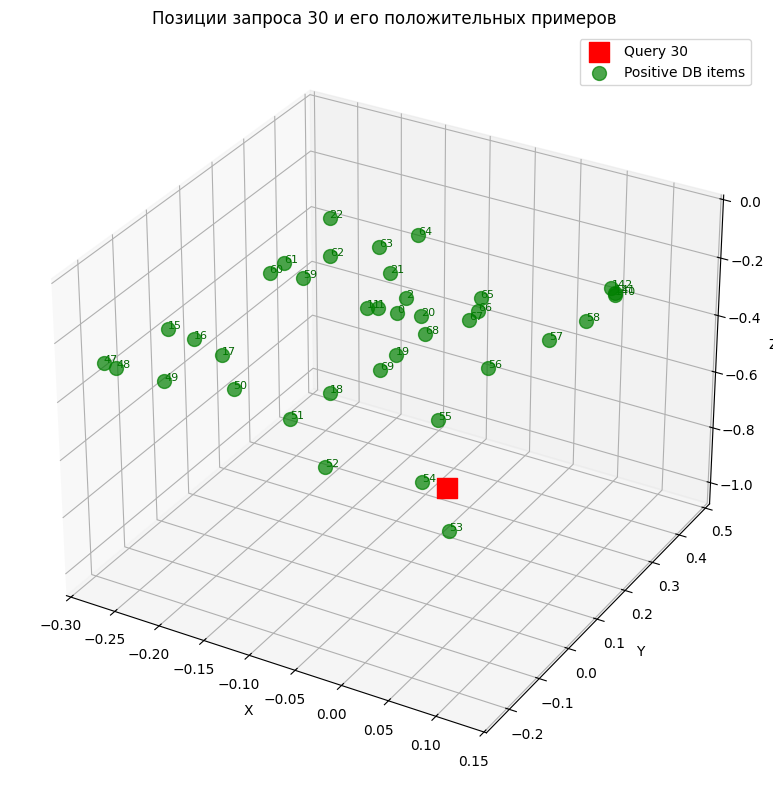

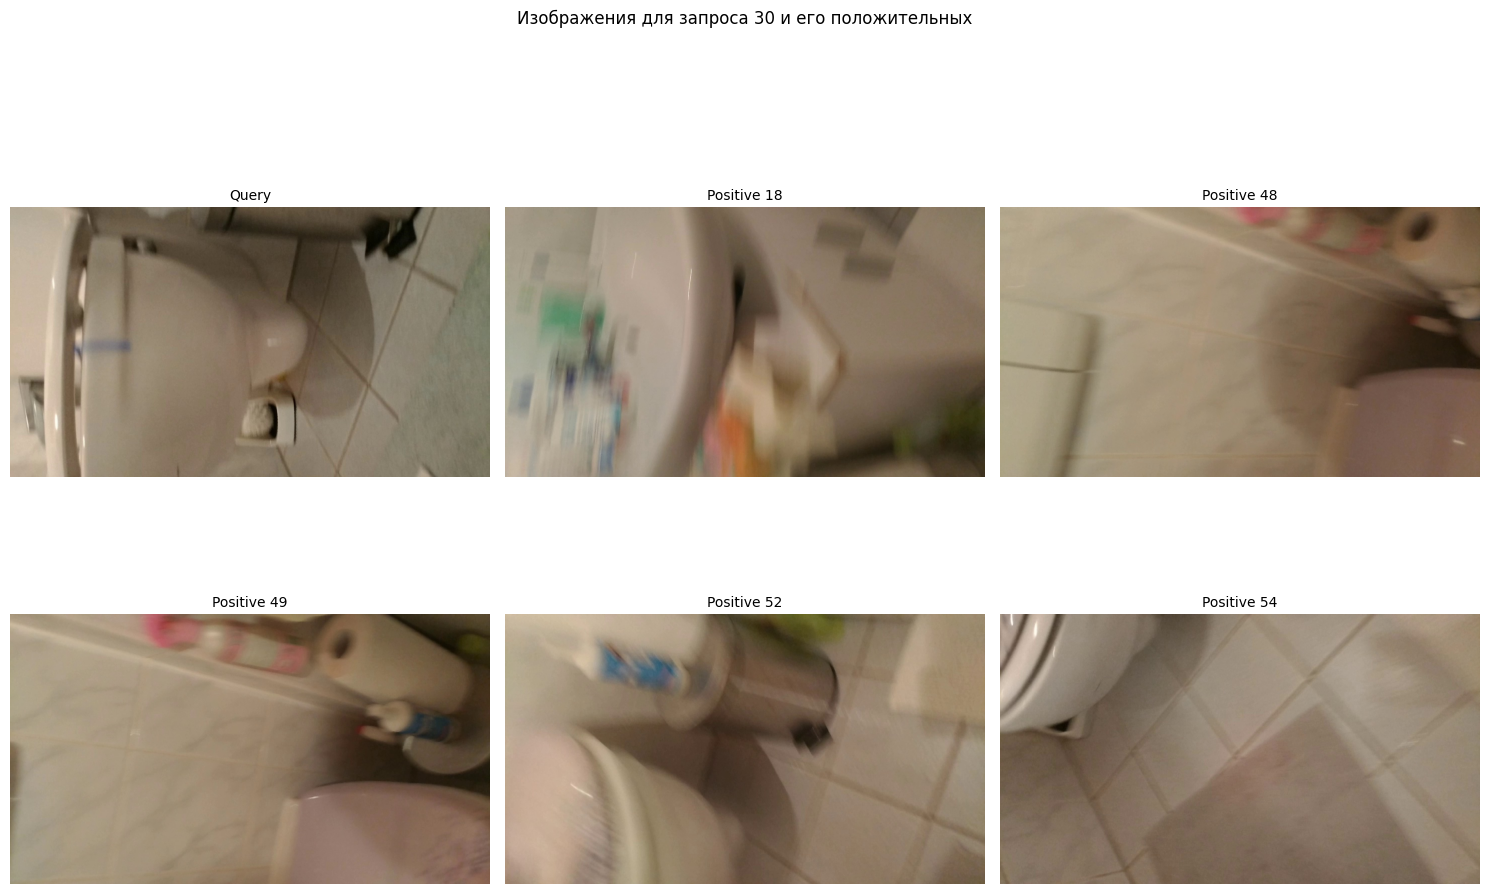

38


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image
import matplotlib.image as mpimg

def show_query_and_positives(database, query_idx, figsize_plot=(10, 8), figsize_images=(15, 10), max_images=5):
    """
    Отображает 3D позиции запроса и его мягких положительных из базы, а также показывает изображения.
    
    Параметры:
        database: объект с атрибутами:
            - soft_positives_per_query[query_idx] – список индексов в базе
            - queries_items[query_idx] – словарь с ключами 'img' (путь) и 'pose' (x,y,z)
            - database[i][0] – словарь с ключами 'img' и 'pose' для i-го элемента базы
        query_idx (int): индекс запроса
        figsize_plot (tuple): размер фигуры для графика позиций
        figsize_images (tuple): размер фигуры для отображения изображений
        max_images (int): максимальное количество изображений для показа (чтобы не перегружать)
    """
    # --- Проверка наличия данных ---
    #if not hasattr(database, 'soft_positives_per_query') or query_idx not in database.soft_positives_per_query:
    #    print(f"Нет данных о мягких положительных для запроса {query_idx}")
    #    return
    
    soft_positives = database.soft_positives_per_query[query_idx]
    if len(soft_positives) == 0:
        print(f"Для запроса {query_idx} нет положительных примеров.")
        # Всё равно можно показать только запрос
        soft_positives = []
    
    # --- Извлечение информации о запросе ---
    query_item = database.queries_items[query_idx]
    query_img_path = query_item['img']
    query_pose = np.array([query_item['pose']['x'], query_item['pose']['y'], query_item['pose']['z']]) \
                 if isinstance(query_item['pose'], dict) else np.array(query_item['pose'])
    
    # --- Извлечение информации о положительных примерах ---
    pos_imgs_paths = []
    pos_poses = []
    valid_indices = []  # для отладки
    
    for idx in soft_positives:
        if idx < len(database) and len(database[idx]) > 0:
            item = database[idx]  # берём первый элемент для этого индекса
            pos_imgs_paths.append(item['img_path'])
            pose = np.array([item['pose']['x'], item['pose']['y'], item['pose']['z']]) \
                   if isinstance(item['pose'], dict) else np.array(item['pose'])
            pos_poses.append(pose)
            valid_indices.append(idx)
        else:
            print(f"Предупреждение: индекс {idx} отсутствует в базе или пуст.")
    
    pos_poses = np.array(pos_poses)
    
    # --- 3D визуализация позиций ---
    fig = plt.figure(figsize=figsize_plot)
    ax = fig.add_subplot(111, projection='3d')
    
    # Точка запроса
    ax.scatter(*query_pose, color='red', s=200, marker='s', label=f'Query {query_idx}', depthshade=False)
    
    # Точки положительных
    if len(pos_poses) > 0:
        ax.scatter(pos_poses[:, 0], pos_poses[:, 1], pos_poses[:, 2],
                   color='green', s=100, marker='o', label='Positive DB items', alpha=0.7, depthshade=False)
        # Добавим подписи индексов
        for i, (pose, idx) in enumerate(zip(pos_poses, valid_indices)):
            ax.text(pose[0], pose[1], pose[2], f'{idx}', size=8, color='darkgreen')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Позиции запроса {query_idx} и его положительных примеров')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # --- Отображение изображений ---
    # Собираем все пути: сначала запрос, затем положительные (ограничиваем max_images)
    all_paths = [query_img_path] + pos_imgs_paths[:max_images]
    titles = ['Query'] + [f'Positive {idx}' for idx in valid_indices[:max_images]]
    
    # Определим размер сетки: например, 2 столбца, строки по необходимости
    n_images = len(all_paths)
    if n_images == 0:
        return
    
    cols = 3  # можно настроить
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize_images)
    axes = axes.flatten() if rows * cols > 1 else [axes]
    
    for ax, img_path, title in zip(axes, all_paths, titles):
        ax.axis('off')
        if os.path.exists(img_path):
            try:
                img = mpimg.imread(img_path)
                ax.imshow(img)
                ax.set_title(title, fontsize=10)
            except Exception as e:
                ax.text(0.5, 0.5, f"Ошибка загрузки\n{img_path}", ha='center', va='center')
                print(f"Не удалось загрузить {img_path}: {e}")
        else:
            ax.text(0.5, 0.5, f"Файл не найден\n{img_path}", ha='center', va='center')
    
    # Скрыть лишние подграфики
    for ax in axes[n_images:]:
        ax.axis('off')
    
    plt.suptitle(f'Изображения для запроса {query_idx} и его положительных', y=1.02)
    plt.tight_layout()
    plt.show()

# Пример использования:
show_query_and_positives(database, 30)
print(len(database.soft_positives_per_query[30]))

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.data import Batch
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import Subset
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import faiss
from functools import partial
from torch_geometric.data import Data, HeteroData, Batch as PyGBatch
import logging


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def _load_graph_file(graph_path):
    if graph_path is None:
        return None
    try:
        return torch.load(graph_path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(graph_path, map_location="cpu")

from torch_geometric.data import Batch

def _graph_to_list(g):
    if g is None:
        return []
    if isinstance(g, (list, tuple)):
        return [x for x in g if x is not None]
    return [g]

GRAPH_KEEP_KEYS = {
    "x",
    "edge_index",
    "edge_attr",
    "node_class",
    "edge_label",
    "edge_u_class",
    "edge_v_class",
}

def _sanitize_graph_obj(g, feat_dim=4):
    """
    Приводит graph к PyG Data с ЕДИНОЙ схемой полей.
    Все графы будут иметь одинаковые ключи:
      x, edge_index, edge_attr, edge_label, edge_u_class, edge_v_class, node_class
    """
    if g is None:
        return None

    if isinstance(g, PyGBatch):
        g = g.to_data_list()
        return g

    if isinstance(g, dict):
        g = dict_to_pyg_data(g, feat_dim=feat_dim)

    if not isinstance(g, (Data, HeteroData)):
        return g

    # x
    x = getattr(g, "x", None)
    if x is None:
        x = torch.zeros((1, feat_dim), dtype=torch.float32)
    elif not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    else:
        x = x.float()

    if x.ndim != 2 or x.shape[0] == 0:
        x = torch.zeros((1, feat_dim), dtype=torch.float32)

    num_nodes = x.shape[0]

    # node_class
    node_class = getattr(g, "node_class", None)
    if node_class is None:
        node_class = torch.zeros((num_nodes,), dtype=torch.long)
    else:
        if not torch.is_tensor(node_class):
            node_class = torch.tensor(node_class, dtype=torch.long)
        node_class = node_class.view(-1).long()
        if node_class.numel() != num_nodes:
            fixed = torch.zeros((num_nodes,), dtype=torch.long)
            m = min(num_nodes, node_class.numel())
            fixed[:m] = node_class[:m]
            node_class = fixed

    # edge_index
    edge_index = getattr(g, "edge_index", None)
    if edge_index is None:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        if not torch.is_tensor(edge_index):
            edge_index = torch.tensor(edge_index, dtype=torch.long)
        else:
            edge_index = edge_index.long()

        if edge_index.ndim != 2 or edge_index.shape[0] != 2:
            edge_index = torch.empty((2, 0), dtype=torch.long)

    # edge-level fields
    edge_attr = getattr(g, "edge_attr", None)
    if edge_attr is None:
        edge_attr = torch.empty((0, 7), dtype=torch.float32)
    else:
        if not torch.is_tensor(edge_attr):
            edge_attr = torch.tensor(np.asarray(edge_attr, dtype=float), dtype=torch.float32)
        else:
            edge_attr = edge_attr.float()
        if edge_attr.ndim != 2:
            edge_attr = torch.empty((0, 7), dtype=torch.float32)

    edge_label = getattr(g, "edge_label", None)
    if edge_label is None:
        edge_label = torch.empty((0,), dtype=torch.long)
    else:
        if not torch.is_tensor(edge_label):
            edge_label = torch.tensor(edge_label, dtype=torch.long)
        else:
            edge_label = edge_label.long()
        edge_label = edge_label.view(-1)

    edge_u_class = getattr(g, "edge_u_class", None)
    if edge_u_class is None:
        edge_u_class = torch.empty((0,), dtype=torch.long)
    else:
        if not torch.is_tensor(edge_u_class):
            edge_u_class = torch.tensor(edge_u_class, dtype=torch.long)
        else:
            edge_u_class = edge_u_class.long()
        edge_u_class = edge_u_class.view(-1)

    edge_v_class = getattr(g, "edge_v_class", None)
    if edge_v_class is None:
        edge_v_class = torch.empty((0,), dtype=torch.long)
    else:
        if not torch.is_tensor(edge_v_class):
            edge_v_class = torch.tensor(edge_v_class, dtype=torch.long)
        else:
            edge_v_class = edge_v_class.long()
        edge_v_class = edge_v_class.view(-1)

    # если есть ребра — выкидываем выходящие за диапазон
    if edge_index.numel() > 0:
        valid = (
            (edge_index[0] >= 0) & (edge_index[0] < num_nodes) &
            (edge_index[1] >= 0) & (edge_index[1] < num_nodes)
        )
        if not valid.all():
            edge_index = edge_index[:, valid]

            if edge_attr.shape[0] == valid.shape[0]:
                edge_attr = edge_attr[valid]
            else:
                edge_attr = edge_attr[:edge_index.shape[1]]

            if edge_label.shape[0] == valid.shape[0]:
                edge_label = edge_label[valid]
            else:
                edge_label = edge_label[:edge_index.shape[1]]

            if edge_u_class.shape[0] == valid.shape[0]:
                edge_u_class = edge_u_class[valid]
            else:
                edge_u_class = edge_u_class[:edge_index.shape[1]]

            if edge_v_class.shape[0] == valid.shape[0]:
                edge_v_class = edge_v_class[valid]
            else:
                edge_v_class = edge_v_class[:edge_index.shape[1]]

    # ВАЖНО: возвращаем Data со ВСЕМИ ключами
    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        edge_label=edge_label,
        edge_u_class=edge_u_class,
        edge_v_class=edge_v_class,
        node_class=node_class,
    )

from torch_geometric.data import Batch as PyGBatch

def _collate_graph_samples(samples, feat_dim=4):
    """
    Collate для inference/cache режима.
    Возвращает dict:
      {
        "graph": PyG Batch,
        "scene": list[str] | None
      }
    """
    out = {}

    # metadata
    indices = [s.get("index") for s in samples if s.get("index") is not None]
    scenes = [s.get("scene") for s in samples if s.get("scene") is not None]

    out["index"] = torch.as_tensor(indices, dtype=torch.long) if len(indices) > 0 else None
    out["scene"] = scenes if len(scenes) > 0 else None

    # graphs
    graph_values = [s.get("graph") for s in samples if s.get("graph") is not None]
    flat_graphs = []

    for g in graph_values:
        g = _sanitize_graph_obj(g, feat_dim=feat_dim)

        if g is None:
            continue

        if isinstance(g, list):
            for x in g:
                x = _ensure_nonempty(_sanitize_graph_obj(x, feat_dim=feat_dim), feat_dim)
                flat_graphs.append(x)
        else:
            flat_graphs.append(_ensure_nonempty(g, feat_dim))

    if len(flat_graphs) == 0:
        out["graph"] = None
    else:
        out["graph"] = PyGBatch.from_data_list(flat_graphs)

    return out



def dict_to_pyg_data(d, feat_dim=4, edge_attr_dim=7):
    if d is None:
        return None

    # x
    x = d.get("x", None)
    if isinstance(x, np.ndarray):
        x = torch.tensor(x, dtype=torch.float32)
    elif x is not None and not torch.is_tensor(x):
        x = torch.tensor(np.asarray(x), dtype=torch.float32)

    if x is None or x.numel() == 0 or x.ndim != 2 or x.shape[0] == 0:
        x = torch.zeros((1, feat_dim), dtype=torch.float32)
    else:
        x = x.float()

    num_nodes = x.shape[0]

    # edge_index
    edge_index = d.get("edge_index", None)
    if edge_index is None:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = (
            torch.tensor(edge_index, dtype=torch.long)
            if not torch.is_tensor(edge_index)
            else edge_index.long()
        )
        if edge_index.ndim != 2 or edge_index.shape[0] != 2:
            edge_index = torch.empty((2, 0), dtype=torch.long)

    # edge_attr
    edge_attr = d.get("edge_attr", None)
    if edge_attr is None:
        edge_attr = torch.empty((0, edge_attr_dim), dtype=torch.float32)
    elif not torch.is_tensor(edge_attr):
        edge_attr = torch.tensor(np.asarray(edge_attr, dtype=float), dtype=torch.float32)
    else:
        edge_attr = edge_attr.float()

    if edge_attr.ndim == 1:
        edge_attr = edge_attr.unsqueeze(0)

    # node_class
    node_class = d.get("node_class", None)
    if node_class is None:
        node_class = torch.zeros((num_nodes,), dtype=torch.long)
    else:
        if not torch.is_tensor(node_class):
            node_class = torch.tensor(node_class, dtype=torch.long)
        else:
            node_class = node_class.long()
        node_class = node_class.view(-1)

        if node_class.numel() != num_nodes:
            fixed = torch.zeros((num_nodes,), dtype=torch.long)
            m = min(num_nodes, node_class.numel())
            fixed[:m] = node_class[:m]
            node_class = fixed

    # Optional edge-level fields
    edge_label = d.get("edge_label", None)
    if edge_label is not None and not torch.is_tensor(edge_label):
        edge_label = torch.tensor(edge_label, dtype=torch.long)
    if torch.is_tensor(edge_label):
        edge_label = edge_label.view(-1)

    edge_u_class = d.get("edge_u_class", None)
    if edge_u_class is not None and not torch.is_tensor(edge_u_class):
        edge_u_class = torch.tensor(edge_u_class, dtype=torch.long)
    if torch.is_tensor(edge_u_class):
        edge_u_class = edge_u_class.view(-1)

    edge_v_class = d.get("edge_v_class", None)
    if edge_v_class is not None and not torch.is_tensor(edge_v_class):
        edge_v_class = torch.tensor(edge_v_class, dtype=torch.long)
    if torch.is_tensor(edge_v_class):
        edge_v_class = edge_v_class.view(-1)

    # Remove invalid edges
    if edge_index.numel() > 0:
        valid = (
            (edge_index[0] >= 0) & (edge_index[0] < num_nodes) &
            (edge_index[1] >= 0) & (edge_index[1] < num_nodes)
        )

        if not valid.all():
            edge_index = edge_index[:, valid]

            if edge_attr is not None:
                edge_attr = edge_attr[valid] if edge_attr.shape[0] == valid.shape[0] else edge_attr[:edge_index.shape[1]]

            if edge_label is not None:
                edge_label = edge_label[valid] if edge_label.shape[0] == valid.shape[0] else edge_label[:edge_index.shape[1]]

            if edge_u_class is not None:
                edge_u_class = edge_u_class[valid] if edge_u_class.shape[0] == valid.shape[0] else edge_u_class[:edge_index.shape[1]]

            if edge_v_class is not None:
                edge_v_class = edge_v_class[valid] if edge_v_class.shape[0] == valid.shape[0] else edge_v_class[:edge_index.shape[1]]

    json_path = d.get("json_path", None)
    if node_class.numel() != x.shape[0]:
        raise ValueError(
            f"Malformed graph: x has {x.shape[0]} nodes, "
            f"but node_class has {node_class.numel()} elements. "
            f"json_path={json_path}"
        )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        node_class=node_class,
        edge_label=edge_label,
        edge_u_class=edge_u_class,
        edge_v_class=edge_v_class,
    )


def _flatten_graphs(graphs):
    """
    Приводит вход к плоскому списку Data-объектов.
    """
    flat = []
    for g in graphs:
        g = _sanitize_graph_obj(g)
        if g is None:
            continue
        if isinstance(g, list):
            flat.extend([x for x in g if x is not None])
        else:
            flat.append(g)
    return flat


def _collate_graph_objects(graphs):
    """
    Collate графов в Batch.
    """
    graphs = _flatten_graphs(graphs)
    if len(graphs) == 0:
        return None

    first = graphs[0]

    if isinstance(first, (Data, HeteroData)):
        return PyGBatch.from_data_list(graphs)

    if torch.is_tensor(first):
        if all(torch.is_tensor(g) and g.shape == first.shape for g in graphs):
            return torch.stack(graphs, dim=0)
        return graphs

    return graphs

def graph_collate_fn(batch, feat_dim=4):
    """
    Unified collate for graph-only pipeline.

    Inference/cache mode:
        batch = list[dict]
        returns dict with graph batch + global indices

    Training mode:
        batch = list[(sample_dict, triplets_local_indexes, triplets_global_indexes)]
        returns:
            batch_samples, triplets_local_indexes, triplets_global_indexes
    """
    first = batch[0]

    # -------------------------
    # Inference / cache mode
    # -------------------------
    if isinstance(first, dict):
        return _collate_graph_samples(batch, feat_dim=feat_dim)

    # -------------------------
    # Training mode
    # -------------------------
    samples, triplets_local_indexes, triplets_global_indexes = zip(*batch)

    graphs = []
    for sample in samples:
        g = _sanitize_graph_obj(sample["graph"], feat_dim=feat_dim)
        if g is None:
            continue
        if isinstance(g, list):
            for x in g:
                graphs.append(_ensure_nonempty(_sanitize_graph_obj(x, feat_dim=feat_dim), feat_dim))
        else:
            graphs.append(_ensure_nonempty(g, feat_dim))

    batch_graph = PyGBatch.from_data_list(graphs) if len(graphs) > 0 else None

    triplets_local_indexes = torch.cat([x[None] for x in triplets_local_indexes], dim=0)
    triplets_global_indexes = torch.cat([x[None] for x in triplets_global_indexes], dim=0)

    for i, (local_indexes, global_indexes) in enumerate(zip(triplets_local_indexes, triplets_global_indexes)):
        local_indexes += len(global_indexes) * i

    batch_samples = {"graph": batch_graph}
    return batch_samples, torch.cat(tuple(triplets_local_indexes)), triplets_global_indexes



def _collate_samples(samples):
    """
    Collate list of sample dicts into a batch dict.

    Each sample can contain:
      - image: Tensor[C,H,W] or Tensor[V,C,H,W] or None
      - graph: graph object or list/tuple of graph objects or None
      - metadata fields: index, scene, pose, img_path, graph_path

    Returns a dict with the same keys, where modality keys are batched.
    """
    out = {}

    # collect metadata always as lists
    for meta_key in ["index", "scene", "pose", "img_path", "graph_path"]:
        values = [s.get(meta_key) for s in samples]
        if any(v is not None for v in values):
            out[meta_key] = values

    # images
    image_values = [s.get("image") for s in samples if s.get("image") is not None]
    if len(image_values) > 0:
        out["image"] = torch.cat(image_values, dim=0)
    else:
        out["image"] = None

    # graphs
    graph_values = [s.get("graph") for s in samples if s.get("graph") is not None]
    if len(graph_values) == 0:
        out["graph"] = None
    else:
        flat_graphs = []
        for g in graph_values:
            if isinstance(g, (list, tuple)):
                flat_graphs.extend([x for x in g if x is not None])
            else:
                flat_graphs.append(g)
        out["graph"] = _collate_graph_objects(flat_graphs)

    return out


def collate_fn(batch):
    """
    Triplet collate.

    Expects batch items:
        (sample_dict, triplets_local_indexes, triplets_global_indexes)

    sample_dict may contain image, graph, or both.

    Returns:
        batch_samples: dict with keys image / graph / metadata
        triplets_local_indexes: Tensor[batch_size * num_neg, 3]
        triplets_global_indexes: Tensor[batch_size, 2 + num_neg]
    """
    samples, triplets_local_indexes, triplets_global_indexes = zip(*batch)

    batch_samples = _collate_samples(list(samples))

    triplets_local_indexes = torch.cat([x[None] for x in triplets_local_indexes], dim=0)
    triplets_global_indexes = torch.cat([x[None] for x in triplets_global_indexes], dim=0)

    # same logic as in your original collate:
    # shift local indexes by the sample size
    for i, (local_indexes, global_indexes) in enumerate(zip(triplets_local_indexes, triplets_global_indexes)):
        local_indexes += len(global_indexes) * i

    return batch_samples, torch.cat(tuple(triplets_local_indexes)), triplets_global_indexes

def compute_cache_graph_only(args, model, subset_ds, cache_shape):
    subset_dl = DataLoader(
        dataset=subset_ds,
        num_workers=args.num_workers,
        batch_size=args.infer_batch_size,
        shuffle=False,
        pin_memory=(args.device == "cuda"),
        collate_fn=graph_collate_fn
    )

    model = model.eval()
    cache = RAMEfficient2DMatrix(cache_shape, dtype=np.float32)

    with torch.no_grad():
        cursor = 0
        subset_indices = getattr(subset_ds, "indices", None)

        for batch in tqdm(subset_dl, ncols=100):
            graph_batch = batch["graph"].to(args.device)

            global_features = model(graph_batch)  # [B, D]
            batch_size = global_features.shape

            if subset_indices is None:
                batch_indices = np.arange(cursor, cursor + batch_size, dtype=np.int32)
            else:
                batch_indices = np.array(subset_indices[cursor:cursor + batch_size], dtype=np.int32)

            cache[batch_indices] = global_features.cpu().numpy()
            cursor += batch_size

    return cache

def graph_collate_fn_cache(batch, feat_dim=4):
    """
    Compatibility wrapper.
    Returns only PyG Batch, but reuses the same sanitization logic.
    """
    out = graph_collate_fn(batch, feat_dim=feat_dim)
    if not isinstance(out, dict):
        raise ValueError("graph_collate_fn_cache expects inference/cache batch of dict samples.")
    if out["graph"] is None:
        raise ValueError("No graphs found in cache batch.")
    return out["graph"]

def _ensure_nonempty(data, feat_dim):
    if data is None:
        return Data(
            x=torch.zeros((1, feat_dim), dtype=torch.float32),
            edge_index=torch.empty((2, 0), dtype=torch.long),
            edge_attr=torch.empty((0, 7), dtype=torch.float32),
            edge_label=torch.empty((0,), dtype=torch.long),
            edge_u_class=torch.empty((0,), dtype=torch.long),
            edge_v_class=torch.empty((0,), dtype=torch.long),
            node_class=torch.full((1,), 0, dtype=torch.long),
        )

    # x
    x = getattr(data, "x", None)
    if x is None or not torch.is_tensor(x):
        x = torch.as_tensor(x, dtype=torch.float32) if x is not None else None

    synthetic_node = False
    if x is None or x.numel() == 0 or x.shape[0] == 0:
        x = torch.zeros((1, feat_dim), dtype=torch.float32)
        synthetic_node = True
    else:
        x = x.float()

    n_nodes = x.shape[0]

    # node_class
    node_class = getattr(data, "node_class", None)
    if node_class is None:
        node_class = torch.full((n_nodes,), 0, dtype=torch.long)
    else:
        if not torch.is_tensor(node_class):
            node_class = torch.tensor(node_class, dtype=torch.long)
        node_class = node_class.view(-1)

        if node_class.numel() != n_nodes:
            fixed = torch.full((n_nodes,), 0, dtype=torch.long)
            m = min(n_nodes, node_class.numel())
            fixed[:m] = node_class[:m]
            node_class = fixed

    # edge_index
    if synthetic_node:
        # если узел синтетический, ребра надо сбросить полностью
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 7), dtype=torch.float32)
        edge_label = torch.empty((0,), dtype=torch.long)
        edge_u_class = torch.empty((0,), dtype=torch.long)
        edge_v_class = torch.empty((0,), dtype=torch.long)
    else:
        edge_index = getattr(data, "edge_index", None)
        if edge_index is None:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        else:
            if not torch.is_tensor(edge_index):
                edge_index = torch.tensor(edge_index, dtype=torch.long)
            else:
                edge_index = edge_index.long()

            if edge_index.ndim != 2 or edge_index.shape[0] != 2:
                edge_index = torch.empty((2, 0), dtype=torch.long)

        # edge_attr / labels
        edge_attr = getattr(data, "edge_attr", None)
        if edge_attr is not None and not torch.is_tensor(edge_attr):
            edge_attr = torch.tensor(np.asarray(edge_attr, dtype=float), dtype=torch.float32)

        edge_label = getattr(data, "edge_label", None)
        if edge_label is not None and not torch.is_tensor(edge_label):
            edge_label = torch.tensor(edge_label, dtype=torch.long)

        edge_u_class = getattr(data, "edge_u_class", None)
        if edge_u_class is not None and not torch.is_tensor(edge_u_class):
            edge_u_class = torch.tensor(edge_u_class, dtype=torch.long)

        edge_v_class = getattr(data, "edge_v_class", None)
        if edge_v_class is not None and not torch.is_tensor(edge_v_class):
            edge_v_class = torch.tensor(edge_v_class, dtype=torch.long)

        # если есть ребра — проверим диапазон индексов и выкинем битые
        if edge_index.numel() > 0:
            valid = (
                (edge_index[0] >= 0) & (edge_index[0] < n_nodes) &
                (edge_index[1] >= 0) & (edge_index[1] < n_nodes)
            )

            if not valid.all():
                edge_index = edge_index[:, valid]

                if edge_attr is not None and torch.is_tensor(edge_attr) and edge_attr.shape[0] == valid.shape[0]:
                    edge_attr = edge_attr[valid]
                elif edge_attr is not None and torch.is_tensor(edge_attr):
                    edge_attr = edge_attr[:edge_index.shape[1]]

                if edge_label is not None and torch.is_tensor(edge_label) and edge_label.shape[0] == valid.shape[0]:
                    edge_label = edge_label[valid]
                elif edge_label is not None and torch.is_tensor(edge_label):
                    edge_label = edge_label[:edge_index.shape[1]]

                if edge_u_class is not None and torch.is_tensor(edge_u_class) and edge_u_class.shape[0] == valid.shape[0]:
                    edge_u_class = edge_u_class[valid]
                elif edge_u_class is not None and torch.is_tensor(edge_u_class):
                    edge_u_class = edge_u_class[:edge_index.shape[1]]

                if edge_v_class is not None and torch.is_tensor(edge_v_class) and edge_v_class.shape[0] == valid.shape[0]:
                    edge_v_class = edge_v_class[valid]
                elif edge_v_class is not None and torch.is_tensor(edge_v_class):
                    edge_v_class = edge_v_class[:edge_index.shape[1]]

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        edge_label=edge_label,
        edge_u_class=edge_u_class,
        edge_v_class=edge_v_class,
        node_class=node_class,
    )
# ---------------------------------------------------------------------
# TripletsDataset
# ---------------------------------------------------------------------

class TripletsDataset(BaseDataset):
    """
    Triplets dataset adapted to the current BaseDataset structure.

    Works with:
      - image-only
      - graph-only
      - image + graph

    Expected BaseDataset fields:
      - self.database_items
      - self.queries_items
      - self.items
      - self.soft_positives_per_query (will be recomputed here)
      - self.scan_to_ref
      - self.ref_to_scans

    Each item is expected to be a dict like:
      {
        "img": "...",
        "graph": "...",
        "scene": "...",
        "pose": np.ndarray([3]) or None
      }
    """

    def __init__(self, args, datasets_folder="datasets", dataset_name="3RScan", split="train", negs_num_per_query=10):
        super().__init__(args, datasets_folder, dataset_name, split)

        self.mining = getattr(args, "mining", "full")
        self.neg_samples_num = getattr(args, "neg_samples_num", 1000)
        self.negs_num_per_query = negs_num_per_query
        self.is_inference = False

        self.resize = getattr(args, "resize", None)
        self.train_positives_dist_threshold = getattr(args, "train_positives_dist_threshold", 10.0)
        self.soft_positives_radius = getattr(args, "soft_positives_radius", 1.0)

        self.modalities = tuple(
            getattr(args, "modalities", getattr(args, "modalites", ["image", "graph"]))
        )
        self.use_images = "image" in self.modalities
        self.use_graphs = "graph" in self.modalities

        identity_transform = transforms.Lambda(lambda x: x)

        if self.resize is not None:
            self.resized_transform = transforms.Compose([
                transforms.Resize(self.resize),
                base_transform
            ])
        else:
            self.resized_transform = base_transform

        q_transforms = [
            transforms.ColorJitter(brightness=args.brightness) if getattr(args, "brightness", None) is not None else identity_transform,
            transforms.ColorJitter(contrast=args.contrast) if getattr(args, "contrast", None) is not None else identity_transform,
            transforms.ColorJitter(saturation=args.saturation) if getattr(args, "saturation", None) is not None else identity_transform,
            transforms.ColorJitter(hue=args.hue) if getattr(args, "hue", None) is not None else identity_transform,
            transforms.RandomPerspective(args.rand_perspective) if getattr(args, "rand_perspective", None) is not None else identity_transform,
            transforms.RandomResizedCrop(size=self.resize, scale=(1 - args.random_resized_crop, 1))
            if getattr(args, "random_resized_crop", None) is not None and self.resize is not None else identity_transform,
            transforms.RandomRotation(degrees=args.random_rotation) if getattr(args, "random_rotation", None) is not None else identity_transform,
            self.resized_transform,
        ]
        self.query_transform = transforms.Compose(q_transforms)

        # Build helper views from BaseDataset storage
        self._sync_views()

        # Hard positives + query filtering
        self._filter_queries_without_soft_positives()

        # Recompute soft positives after query filtering
        self.soft_positives_per_query = self._build_soft_positives(radius=self.soft_positives_radius)

        if self.mining == "full":
            self.neg_cache = [np.empty((0,), dtype=np.int32) for _ in range(self.queries_num)]

        self.triplets_global_indexes = torch.empty((0, 2 + self.negs_num_per_query), dtype=torch.long)

        # msls_weighted support
        self.weights = None
        if self.mining == "msls_weighted":
            self._build_msls_weights()

    # -----------------------------------------------------------------
    # Views / indexing
    # -----------------------------------------------------------------

    def _sync_views(self):
        self.database_num = len(self.database_items)
        self.queries_num = len(self.queries_items)

        self.database_paths = [item.get("img") for item in self.database_items]
        self.queries_paths = [item.get("img") for item in self.queries_items]
        self.images_paths = self.database_paths + self.queries_paths

        self.database_utms = np.array(
            [item["pose"] for item in self.database_items if item.get("pose") is not None],
            dtype=np.float32
        ) if any(item.get("pose") is not None for item in self.database_items) else np.empty((0, 3), dtype=np.float32)

        self.queries_utms = np.array(
            [item["pose"] for item in self.queries_items if item.get("pose") is not None],
            dtype=np.float32
        ) if any(item.get("pose") is not None for item in self.queries_items) else np.empty((0, 3), dtype=np.float32)

        self.database_pose_indices = np.array(
            [i for i, item in enumerate(self.database_items) if item.get("pose") is not None],
            dtype=np.int32
        )
        self.queries_pose_indices = np.array(
            [i for i, item in enumerate(self.queries_items) if item.get("pose") is not None],
            dtype=np.int32
        )

        self.items = self.database_items + self.queries_items

    def _build_item_sample(self, item, is_query=False, with_meta=True):
        """
        Build a sample dict for one item.
        The returned dict always contains image/graph keys (possibly None),
        plus metadata if with_meta=True.
        """
        sample = {}

        if with_meta:
            sample["scene"] = item.get("scene")
            sample["pose"] = item.get("pose")
            sample["img_path"] = item.get("img")
            sample["graph_path"] = item.get("graph")

        if self.use_images:
            img_path = item.get("img")
            if img_path is not None:
                img = path_to_pil_img(img_path)
                img = self.query_transform(img) if is_query else self.resized_transform(img)
                sample["image"] = img
            else:
                sample["image"] = None
        else:
            sample["image"] = None

        if self.use_graphs:
            graph_path = item.get("graph")
            sample["graph"] = _load_graph_file(graph_path) if graph_path is not None else None
        else:
            sample["graph"] = None

        return sample


    def _filter_queries_without_soft_positives(self):
        keep = []
        for i, q_item in enumerate(self.queries_items):
            has_pose = q_item.get("pose") is not None
            has_positives = len(self.soft_positives_per_query[i]) > 0
            if has_pose and has_positives:
                keep.append(i)

        removed = len(self.queries_items) - len(keep)
        if removed > 0:
            logging.info(
                f"Removed {removed} queries without soft positives or without pose. "
                f"They will not be used for training."
            )

        self.queries_items = [self.queries_items[i] for i in keep]
        self.queries_paths = [self.queries_paths[i] for i in keep]
        self.soft_positives_per_query = [
            np.asarray(self.soft_positives_per_query[i], dtype=np.int32)
            for i in keep
        ]

        self.queries_num = len(self.queries_items)
        self.items = self.database_items + self.queries_items

    def _complete_negative_indexes(self, query_index, num_negatives=None):
        """
        Sample negatives only from a random scene whose reference != query reference.
        All negatives are taken from the SAME randomly chosen foreign reference scene.
        """
        if num_negatives is None:
            num_negatives = self.negs_num_per_query

        query_item = self.queries_items[query_index]
        query_scene = query_item["scene"]
        query_ref = self.scan_to_ref.get(query_scene, query_scene)

        # all references except the query reference
        other_refs = [ref for ref in self.ref_to_scans.keys() if ref != query_ref]
        if len(other_refs) == 0:
            raise RuntimeError(f"No foreign reference scenes found for query ref='{query_ref}'")

        # try several times to find a non-empty foreign reference scene
        for _ in range(50):
            chosen_ref = np.random.choice(other_refs)

            candidate_db_indexes = [
                db_idx
                for db_idx, db_item in enumerate(self.database_items)
                if self.scan_to_ref.get(db_item["scene"], db_item["scene"]) == chosen_ref
            ]

            if len(candidate_db_indexes) == 0:
                continue

            replace = len(candidate_db_indexes) < num_negatives
            neg_indexes = np.random.choice(
                candidate_db_indexes,
                size=num_negatives,
                replace=replace
            ).astype(np.int32)

            return neg_indexes

        raise RuntimeError(
            f"Could not sample negatives for query_index={query_index} "
            f"because no non-empty foreign reference scene was found."
        )

    # -----------------------------------------------------------------
    # Dataset API
    # -----------------------------------------------------------------

    def __len__(self):
        if self.is_inference:
            return len(self.items)
        return len(self.triplets_global_indexes)

    def __getitem__(self, index):
        if self.is_inference:
            item = self.items[index]
            return self._build_item_sample(item, is_query=(index >= self.database_num), with_meta=True)

        query_index, best_positive_index, neg_indexes = torch.split(
            self.triplets_global_indexes[index],
            (1, 1, self.negs_num_per_query)
        )

        query_index = int(query_index.item())
        best_positive_index = int(best_positive_index.item())
        neg_indexes = [int(i.item()) for i in neg_indexes]

        query_item = self.queries_items[query_index]
        positive_item = self.database_items[best_positive_index]
        negative_items = [self.database_items[i] for i in neg_indexes]

        items = [query_item, positive_item, *negative_items]

        sample = {}

        if self.use_images:
            images = [
                self._build_item_sample(items[0], is_query=True, with_meta=False)["image"],
                self._build_item_sample(items[1], is_query=False, with_meta=False)["image"],
                *[self._build_item_sample(it, is_query=False, with_meta=False)["image"] for it in items[2:]]
            ]
            sample["image"] = torch.stack(images, dim=0)
        else:
            sample["image"] = None

        if self.use_graphs:
            graphs = [
                self._build_item_sample(items[0], is_query=True, with_meta=False)["graph"],
                self._build_item_sample(items[1], is_query=False, with_meta=False)["graph"],
                *[self._build_item_sample(it, is_query=False, with_meta=False)["graph"] for it in items[2:]]
            ]
            sample["graph"] = graphs
        else:
            sample["graph"] = None

        triplets_local_indexes = torch.empty((0, 3), dtype=torch.int64)
        for neg_num in range(len(neg_indexes)):
            triplets_local_indexes = torch.cat(
                (triplets_local_indexes, torch.tensor([0, 1, 2 + neg_num]).reshape(1, 3))
            )

        return sample, triplets_local_indexes, self.triplets_global_indexes[index]

    def __repr__(self):
        return  (f"< {self.__class__.__name__}, {self.dataset_name} - #database: {len(self.database_items)}; #queries: {len(self.queries_items)} >")

    def get_positives(self):
        return self.soft_positives_per_query

    # -----------------------------------------------------------------
    # Cache / model utilities
    # -----------------------------------------------------------------

    @staticmethod
    def _move_to_device(obj, device):
        if obj is None:
            return None
        if torch.is_tensor(obj):
            return obj.to(device, non_blocking=True)
        if isinstance(obj, dict):
            return {k: TripletsDataset._move_to_device(v, device) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return type(obj)(TripletsDataset._move_to_device(x, device) for x in obj)
        if hasattr(obj, "to"):
            try:
                return obj.to(device)
            except Exception:
                return obj
        return obj

    def _prepare_model_input(self, batch):
        """
        Extract only modality tensors/objects from a collated batch dict.
        If there is a single modality, returns that object directly.
        If there are multiple modalities, returns a dict.
        """
        if not isinstance(batch, dict):
            return batch

        model_inputs = {}
        if self.use_images and batch.get("image") is not None:
            model_inputs["image"] = batch["image"]
        if self.use_graphs and batch.get("graph") is not None:
            model_inputs["graph"] = batch["graph"]

        if len(model_inputs) == 1:
            return next(iter(model_inputs.values()))

        return model_inputs

    @staticmethod
    def _split_model_output(output):
        """
        Accepts:
          - (local_features, global_features)
          - {"local_features": ..., "global_features": ...}
          - {"local": ..., "global": ...}
          - global tensor only

        Returns: local_features, global_features
        """
        local_features = None
        global_features = None

        if isinstance(output, dict):
            local_features = output.get("local_features", output.get("local", None))
            global_features = output.get("global_features", output.get("global", None))
            if global_features is None and len(output) == 1:
                global_features = next(iter(output.values()))
        elif isinstance(output, (tuple, list)):
            if len(output) == 1:
                global_features = output[0]
            elif len(output) >= 2:
                local_features, global_features = output[0], output[1]
        else:
            global_features = output

        return local_features, global_features

    @staticmethod
    def compute_cache(args, model, subset_ds, cache_shape):
        """
        Compute the cache containing global embeddings, used to find best positives
        and hardest negatives.

        The dataset used here should be in inference mode, i.e. __getitem__ returns sample dicts.
        """
        subset_dl = DataLoader(
            dataset=subset_ds,
            num_workers=args.num_workers,
            batch_size=args.infer_batch_size,
            shuffle=False,
            pin_memory=(args.device == "cuda"),
            collate_fn=partial(graph_collate_fn_cache, feat_dim=4)
        )
        model = model.eval()

        cache = RAMEfficient2DMatrix(cache_shape, dtype=np.float32)

        # If the model returns local feature maps, we create the local cache lazily.
        with torch.no_grad():
            cursor = 0
            subset_indices = getattr(subset_ds, "indices", None)

            for batch in tqdm(subset_dl, ncols=100):
                #print("batch, cache", batch)
                batch = TripletsDataset._move_to_device(batch, args.device)

                output = model(batch)
                global_features = output

                if global_features is None:
                    raise RuntimeError("Model must return global features for cache computation.")


                batch_size = global_features.shape[0]

                if subset_indices is None:
                    batch_indices = np.arange(cursor, cursor + batch_size, dtype=np.int32)
                else:
                    batch_indices = np.array(subset_indices[cursor:cursor + batch_size], dtype=np.int32)

                cache[batch_indices] = global_features.detach().cpu().numpy()

                cursor += batch_size

        return cache
        

    def get_query_features(self, query_index, cache):
        query_features = cache[query_index + self.database_num]
        if query_features is None:
            raise RuntimeError(
                f"For query {self.queries_paths[query_index]} with index {query_index} "
                f"features have not been computed."
            )
        return query_features

    def get_best_positive_index(self, args, query_index, cache, query_features):
        positives_indexes = self.soft_positives_per_query[query_index]
        positives_features = cache[positives_indexes]

        faiss_index = faiss.IndexFlatL2(args.features_dim)
        faiss_index.add(positives_features)

        _, best_positive_num = faiss_index.search(query_features.reshape(1, -1), 1)
        best_positive_index = positives_indexes[best_positive_num[0][0]]
        return best_positive_index

    def get_hardest_negatives_indexes(self, args, cache, query_features, neg_samples):
        neg_samples = np.asarray(neg_samples, dtype=np.int32).reshape(-1)
        if len(neg_samples) == 0:
            return np.empty((0,), dtype=np.int32)

        neg_features = cache[neg_samples]
        faiss_index = faiss.IndexFlatL2(args.features_dim)
        faiss_index.add(neg_features)

        k = min(self.negs_num_per_query, len(neg_samples))
        _, neg_nums = faiss_index.search(query_features.reshape(1, -1), k)
        neg_nums = neg_nums.reshape(-1)
        neg_indexes = neg_samples[neg_nums].astype(np.int32)
        return neg_indexes

    # -----------------------------------------------------------------
    # Triplet mining
    # -----------------------------------------------------------------

    def compute_triplets(self, args, model):
        self.is_inference = True

        if self.mining == "full":
            self.compute_triplets_full(args, model)
        elif self.mining in ["partial", "msls_weighted"]:
            self.compute_triplets_partial(args, model)
        elif self.mining == "random":
            self.compute_triplets_random(args, model)
        else:
            raise ValueError(f"Unknown mining method: {self.mining}")

        self.is_inference = False

    def compute_triplets_random(self, args, model):
        self.triplets_global_indexes = []

        refresh_rate = min(self.queries_num, getattr(args, "cache_refresh_rate", self.queries_num))
        sampled_queries_indexes = np.random.choice(self.queries_num, refresh_rate, replace=False)

        positives_indexes = [self.soft_positives_per_query[i] for i in sampled_queries_indexes]
        positives_indexes = [p for pos in positives_indexes for p in pos]
        positives_indexes = list(np.unique(positives_indexes))

        subset_indices = positives_indexes + list(sampled_queries_indexes + self.database_num)
        subset_ds = Subset(self, subset_indices)

        cache = self.compute_cache(args, model, subset_ds, (len(self.items), args.features_dim))

        for query_index in tqdm(sampled_queries_indexes, ncols=100):
            query_features = self.get_query_features(query_index, cache)
            best_positive_index = self.get_best_positive_index(args, query_index, cache, query_features)

            soft_positives = self.soft_positives_per_query[query_index]
            neg_indexes = self._complete_negative_indexes(query_index)

            self.triplets_global_indexes.append((query_index, best_positive_index, *neg_indexes))

        self.triplets_global_indexes = torch.tensor(self.triplets_global_indexes, dtype=torch.long)

    def compute_triplets_full(self, args, model):
        self.triplets_global_indexes = []

        refresh_rate = min(self.queries_num, getattr(args, "cache_refresh_rate", self.queries_num))
        sampled_queries_indexes = np.random.choice(self.queries_num, refresh_rate, replace=False)

        database_indexes = list(range(self.database_num))
        subset_indices = database_indexes + list(sampled_queries_indexes + self.database_num)
        subset_ds = Subset(self, subset_indices)

        cache = self.compute_cache(args, model, subset_ds, (len(self.items), args.features_dim))

        for query_index in tqdm(sampled_queries_indexes, ncols=100):
            query_features = self.get_query_features(query_index, cache)
            best_positive_index = self.get_best_positive_index(args, query_index, cache, query_features)

            neg_indexes = np.random.choice(
                self.database_num,
                size=min(self.neg_samples_num, self.database_num),
                replace=False
            )

            soft_positives = self.soft_positives_per_query[query_index]
            neg_indexes = self._complete_negative_indexes(query_index)

            self.neg_cache[query_index] = neg_indexes
            self.triplets_global_indexes.append((query_index, best_positive_index, *neg_indexes))

        self.triplets_global_indexes = torch.tensor(self.triplets_global_indexes, dtype=torch.long)

    def compute_triplets_partial(self, args, model):
        self.triplets_global_indexes = []

        refresh_rate = min(self.queries_num, getattr(args, "cache_refresh_rate", self.queries_num))
        if self.mining == "partial":
            sampled_queries_indexes = np.random.choice(self.queries_num, refresh_rate, replace=False)
        elif self.mining == "msls_weighted":
            sampled_queries_indexes = np.random.choice(self.queries_num, refresh_rate, replace=False, p=self.weights)
        else:
            raise ValueError(f"Unsupported mining method in partial stage: {self.mining}")

        db_neg_count = min(self.database_num, self.neg_samples_num)
        sampled_database_indexes = np.random.choice(self.database_num, db_neg_count, replace=False)

        positives_indexes = [self.soft_positives_per_query[i] for i in sampled_queries_indexes]
        positives_indexes = [p for pos in positives_indexes for p in pos]

        database_indexes = list(np.unique(list(sampled_database_indexes) + positives_indexes))

        subset_indices = database_indexes + list(sampled_queries_indexes + self.database_num)
        subset_ds = Subset(self, subset_indices)

        cache = self.compute_cache(args, model, subset_ds, cache_shape=(len(self.items), args.features_dim))

        for query_index in tqdm(sampled_queries_indexes, ncols=100):
            query_features = self.get_query_features(query_index, cache)
            best_positive_index = self.get_best_positive_index(args, query_index, cache, query_features)

            soft_positives = self.soft_positives_per_query[query_index]
            neg_indexes = self._complete_negative_indexes(query_index)

            self.triplets_global_indexes.append((query_index, best_positive_index, *neg_indexes))

        self.triplets_global_indexes = torch.tensor(self.triplets_global_indexes, dtype=torch.long)

/home/pinkin_ek/projects/Scene_graph_localization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch, HeteroData
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool


class VPRGraphEncoder(nn.Module):
    def __init__(self,
                 in_dim,
                 hidden_dim=256,
                 n_layers=3,
                 proj_dim=128,
                 num_node_classes=None,
                 node_emb_dim=64,
                 dropout=0.1):
        super().__init__()
        self.use_node_class = (num_node_classes is not None)
        self.node_emb = None
        if self.use_node_class:
            self.node_emb = nn.Embedding(num_node_classes, node_emb_dim)
            nn.init.xavier_uniform_(self.node_emb.weight)
        eff_in_dim = in_dim + (node_emb_dim if self.use_node_class else 0)
        self.input_mlp = nn.Sequential(
            nn.Linear(eff_in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True)
        )
        self.convs = nn.ModuleList()
        for _ in range(n_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(p=dropout)
        self.pool_out_dim = hidden_dim * 2
        self.proj = nn.Sequential(
            nn.Linear(self.pool_out_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )
        self._proj_dim = proj_dim

    def forward(self, batch: Batch):
        x = batch.x
        if self.use_node_class and hasattr(batch, 'node_class') and batch.node_class is not None:
            node_cls = batch.node_class.long().to(x.device)
            emb = self.node_emb(node_cls)
            x = torch.cat([x, emb], dim=1)
        h = self.input_mlp(x)
        for conv in self.convs:
            h = conv(h, batch.edge_index)
            h = self.act(h)
            h = self.drop(h)
        hg_mean = global_mean_pool(h, batch.batch)
        hg_max  = global_max_pool(h, batch.batch)
        hg = torch.cat([hg_mean, hg_max], dim=1)
        z = self.proj(hg)
        z = F.normalize(z, p=2, dim=1)
        return z

    @property
    def out_dim(self):
        return self._proj_dim


In [8]:
class RAMEfficient2DMatrix:
    """This class behaves similarly to a numpy.ndarray initialized
    with np.zeros(), but is implemented to save RAM when the rows
    within the 2D array are sparse. In this case it's needed because
    we don't always compute features for each image, just for few of
    them"""
    def __init__(self, shape, dtype=np.float32):
        self.shape = shape
        self.dtype = dtype
        self.matrix = [None] * shape[0]
    def __setitem__(self, indexes, vals):
        assert vals.shape[1] == self.shape[1], f"{vals.shape[1]} {self.shape[1]}"
        for i, val in zip(indexes, vals):
            self.matrix[i] = val.astype(self.dtype, copy=False)
    def __getitem__(self, index):
        if hasattr(index, "__len__"):
            return np.array([self.matrix[i] for i in index])
        else:
            return self.matrix[index]

class RAMEfficient4DMatrix:
    """This class behaves similarly to a numpy.ndarray initialized
    with np.zeros(), but is implemented to save RAM when the rows
    within the 3D array are sparse. In this case it's needed because
    we don't always compute features for each image, just for few of
    them"""
    def __init__(self, shape, dtype=np.float32):
        self.shape = shape
        self.dtype = dtype
        self.matrix = [None] * shape[0]
    def __setitem__(self, indexes, vals):
        assert vals.shape[1] == self.shape[1], f"{vals.shape[1]} {self.shape[1]}"
        assert vals.shape[2] == self.shape[2], f"{vals.shape[2]} {self.shape[2]}"
        assert vals.shape[3] == self.shape[3], f"{vals.shape[3]} {self.shape[3]}"
        for i, val in zip(indexes, vals):
            self.matrix[i] = val.astype(self.dtype, copy=False)
    def __getitem__(self, index):
        if hasattr(index, "__len__"):
            return np.array([self.matrix[i] for i in index])
        else:
            return self.matrix[index]

In [9]:
from torch.utils.data import DataLoader, Subset
import numpy as np
import faiss
import torch
from tqdm import tqdm

def _build_subset_loader(dataset, indices, args, shuffle=False):
    subset = Subset(dataset, indices)
    return DataLoader(
        subset,
        batch_size=args.infer_batch_size,
        shuffle=shuffle,
        num_workers=args.num_workers,
        collate_fn=graph_collate_fn,
        pin_memory=(args.device == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def _extract_embeddings(model, loader, device):
    model.eval()
    all_embs = []
    all_scenes = []

    for batch_samples in tqdm(loader, desc="Extract embeddings", ncols=100):
        #print("TEST BATCH[0]", batch[0])        
        batch_graph = batch_samples['graph'].to(device)
        emb = model(batch_graph).detach().float().cpu()

        scenes = batch_samples["scene"]
        if isinstance(scenes, str):
            scenes = [scenes]

        all_embs.append(emb)
        all_scenes.extend(list(scenes))

    all_embs = torch.cat(all_embs, dim=0).numpy().astype(np.float32)
    return all_embs, all_scenes

def test(args, dataset, model, device=None, ks=(1, 5, 10, 20)):
    if device is None:
        device = args.device

    # database = первые database_items
    db_indices = list(range(len(dataset.database_items)))
    # queries = всё остальное
    q_indices = list(range(len(dataset.database_items), len(dataset.items)))

    db_loader = _build_subset_loader(dataset, db_indices, args, shuffle=False)
    q_loader = _build_subset_loader(dataset, q_indices, args, shuffle=False)

    db_embs, db_scenes = _extract_embeddings(model, db_loader, device)
    q_embs, q_scenes = _extract_embeddings(model, q_loader, device)

    faiss.normalize_L2(db_embs)
    faiss.normalize_L2(q_embs)

    index = faiss.IndexFlatIP(db_embs.shape[1])
    index.add(db_embs)

    max_k = max(ks)
    _, nn_idx = index.search(q_embs, max_k)

    def room_id(scene_name):
        return dataset.scan_to_ref.get(scene_name, scene_name)

    q_rooms = [room_id(s) for s in q_scenes]
    db_rooms = [room_id(s) for s in db_scenes]

    recalls = {}
    for k in ks:
        hit = 0
        for qi in range(len(q_rooms)):
            retrieved_rooms = [db_rooms[j] for j in nn_idx[qi, :k]]
            if q_rooms[qi] in retrieved_rooms:
                hit += 1
        recalls[f"R@{k}"] = hit / max(1, len(q_rooms))

    recalls_str = ", ".join([f"R@{k}: {recalls[f'R@{k}']*100:.2f}" for k in ks])
    return recalls, recalls_str, nn_idx

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch

def _load_img(path):
    if path is None or not os.path.exists(path):
        return None
    return Image.open(path).convert("RGB")

def _show_img(ax, path, title=""):
    img = _load_img(path)
    img_rotated_cw = img.transpose(Image.ROTATE_270)
    if img is None:
        ax.set_title(title + "\n[no image]")
        ax.axis("off")
        return

    ax.imshow(img_rotated_cw)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

def _room_id(dataset, scene_name):
    return dataset.scan_to_ref.get(scene_name, scene_name)

def visualize_triplet_images(dataset, triplets_global_indexes, num_triplets_to_show=1):
    """
    dataset: TripletsDataset
    triplets_global_indexes: Tensor[B, K]
        [query_index, positive_index, neg1, neg2, ...]
    """
    if not torch.is_tensor(triplets_global_indexes):
        triplets_global_indexes = torch.as_tensor(triplets_global_indexes)

    B, K = triplets_global_indexes.shape
    num_triplets_to_show = min(num_triplets_to_show, B)

    for b in range(num_triplets_to_show):
        gidx = triplets_global_indexes[b].detach().cpu().tolist()

        q_idx = int(gidx[0])
        p_idx = int(gidx[1])
        neg_idx = [int(x) for x in gidx[2:]]

        q_item = dataset.queries_items[q_idx]
        p_item = dataset.database_items[p_idx]
        n_items = [dataset.database_items[i] for i in neg_idx]

        q_scene = q_item.get("scene")
        p_scene = p_item.get("scene")
        n_scenes = [it.get("scene") for it in n_items]

        q_ref = _room_id(dataset, q_scene)
        p_ref = _room_id(dataset, p_scene)
        n_refs = [_room_id(dataset, s) for s in n_scenes]

        q_img_path = q_item.get("img")
        p_img_path = p_item.get("img")
        n_img_paths = [it.get("img") for it in n_items]

        print("=" * 110)
        print(f"TRIPLET #{b}")
        print(f"QUERY      | q_idx={q_idx} | scene={q_scene} | ref={q_ref} | img={q_img_path}")
        print(f"POSITIVE   | db_idx={p_idx} | scene={p_scene} | ref={p_ref} | img={p_img_path}")
        for i, it in enumerate(n_items):
            print(f"NEGATIVE_{i+1} | db_idx={neg_idx[i]} | scene={n_scenes[i]} | ref={n_refs[i]} | img={n_img_paths[i]}")

        n_plots = 2 + len(n_items)
        fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
        if n_plots == 1:
            axes = [axes]

        _show_img(
            axes[0],
            q_img_path,
            title=f"QUERY\nscene={q_scene}\nref={q_ref}\nidx={q_idx}",
        )
        _show_img(
            axes[1],
            p_img_path,
            title=f"POSITIVE\nscene={p_scene}\nref={p_ref}\nidx={p_idx}",
        )

        for j, path in enumerate(n_img_paths):
            _show_img(
                axes[2 + j],
                path,
                title=f"NEGATIVE_{j+1}\nscene={n_scenes[j]}\nref={n_refs[j]}\nidx={neg_idx[j]}",
            )

        plt.tight_layout()
        plt.show()

2026-03-23 15:01:42,571 - INFO - Arguments: Namespace(train_batch_size=1024, infer_batch_size=1024, criterion='triplet', margin=0.1, epochs_num=50, patience=3, lr=1e-05, optim='adam', cache_refresh_rate=1024, queries_per_epoch=5000, negs_num_per_query=2, neg_samples_num=1000, mining='partial', l2='before_pool', pca_dim=None, registers=False, features_dim=128, seed=0, resume=None, device='cuda', num_workers=8, resize=[224, 224], dense_feature_map_size=[61, 61, 128], test_method='hard_resize', majority_weight=0.01, efficient_ram_testing=False, val_positive_dist_threshold=25, train_positives_dist_threshold=10, recall_values=[1, 5, 10, 20], rerank_num=100, modalities=['graph'], brightness=None, contrast=None, saturation=None, hue=None, rand_perspective=None, horizontal_flip=False, random_resized_crop=None, random_rotation=None, datasets_folder='/mnt/external_usb_hdd/6YL/Datasets', dataset_name='3RScan', pca_dataset_folder=None, save_dir='/home/pinkin_ek/projects/Scene_graph_localization/da

Ignored unknown arguments: ['--f=/home/pinkin_ek/.local/share/jupyter/runtime/kernel-v2-5082AxTOjl3unpBd.json']
SCAN LEN 25
3


2026-03-23 15:01:42,846 - INFO - Removed 19 queries without soft positives or without pose. They will not be used for training.
2026-03-23 15:01:42,873 - INFO - Train query set: < TripletsDataset, 3RScan - #database: 510; #queries: 1721 >


ХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХ
BUILD_SOFT_POSITIVES, DB 3
TREES 3
queries 1740
ХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХХ
BUILD_SOFT_POSITIVES, DB 3
TREES 3
queries 1721
SCAN LEN 25
3


2026-03-23 15:01:47,163 - INFO - Test set: < BaseDataset, 3RScan - #database: 1576; #queries: 5439 >


...

2026-03-23 15:01:47,326 - INFO - Start training epoch: 00
2026-03-23 15:01:47,327 - DEBUG - Cache: 0 / 5
100%|█████████████████████████████████████████████████████████| 1024/1024 [00:00<00:00, 4802.17it/s]


1024 Количество триплетов


  0%|                                                                         | 0/1 [00:00<?, ?it/s]2026-03-23 15:01:51,386 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=9.0.
2026-03-23 15:01:51,387 - DEBUG - findfont: score(FontEntry(fname='/home/pinkin_ek/projects/Scene_graph_localization/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-03-23 15:01:51,388 - DEBUG - findfont: score(FontEntry(fname='/home/pinkin_ek/projects/Scene_graph_localization/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-03-23 15:01:51,388 - DEBUG - findfont: score(FontEntry(fname='/home/pinkin_ek/projects/Scene_graph_localization/.venv/lib/pyth

TRIPLET #0
QUERY      | q_idx=704 | scene=02b33e03-be2b-2d54-9129-5d28efdd68fa | ref=02b33e01-be2b-2d54-93fb-4145a709cec5 | img=/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33e03-be2b-2d54-9129-5d28efdd68fa/sequence/frame-000143.color.jpg
POSITIVE   | db_idx=254 | scene=02b33e01-be2b-2d54-93fb-4145a709cec5 | ref=02b33e01-be2b-2d54-93fb-4145a709cec5 | img=/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33e01-be2b-2d54-93fb-4145a709cec5/sequence/frame-000111.color.jpg
NEGATIVE_1 | db_idx=131 | scene=02b33dfb-be2b-2d54-92d2-cd012b2b3c40 | ref=02b33dfb-be2b-2d54-92d2-cd012b2b3c40 | img=/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000131.color.jpg
NEGATIVE_2 | db_idx=30 | scene=02b33dfb-be2b-2d54-92d2-cd012b2b3c40 | ref=02b33dfb-be2b-2d54-92d2-cd012b2b3c40 | img=/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence/frame-000030.color.jpg


2026-03-23 15:01:51,437 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/didot/GFSDidotBold.otf', name='GFS Didot', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-03-23 15:01:51,437 - DEBUG - findfont: score(FontEntry(fname='/usr/share/texmf/fonts/opentype/public/tex-gyre/texgyreheros-regular.otf', name='TeX Gyre Heros', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-03-23 15:01:51,438 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/open-sans/OpenSans-Regular.ttf', name='Open Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-03-23 15:01:51,438 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-03-23 15:01:51,438 - DEBUG - findfont: scor

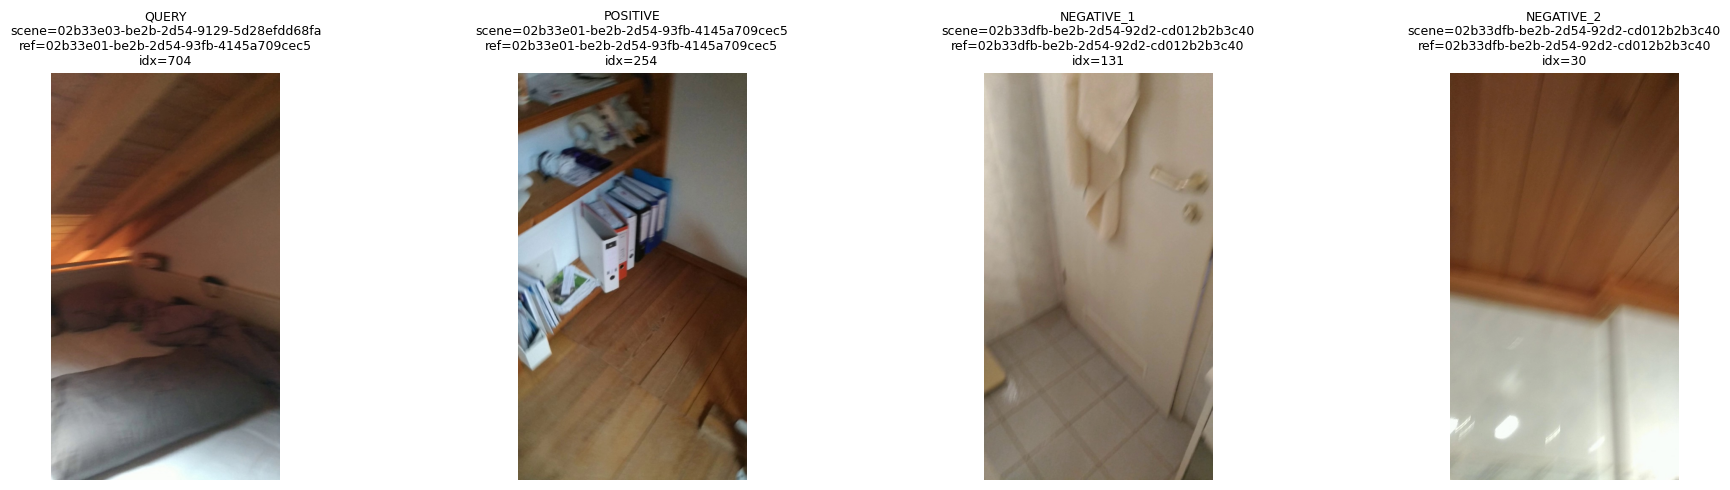

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.31s/it]
2026-03-23 15:01:52,267 - DEBUG - global loss = 0.085866
2026-03-23 15:01:52,267 - DEBUG - Epoch[00](0/5): current batch triplet loss = 0.0859, average epoch triplet loss = 0.0859


total_loss 0.08586616814136505


Extract embeddings:   0%|                                                     | 0/6 [00:30<?, ?it/s]


In [11]:
import math
import torch
import logging
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import multiprocessing
from os.path import join
from datetime import datetime
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader
torch.backends.cudnn.benchmark= True  # Provides a speedup

#import util
import argparse
import warnings
warnings.filterwarnings('ignore')
import os

logging.basicConfig(
    level=logging.DEBUG,  # <-- ключевое изменение
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler()
    ]
)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#### Initial setup: parser, logging...
def train_baseline(args):
    start_time = datetime.now()
    args.save_dir = join("logs", args.save_dir, start_time.strftime('%Y-%m-%d_%H-%M-%S'))
    logging.info(f"Arguments: {args}")
    logging.info(f"The outputs are being saved in {args.save_dir}")
    logging.info(f"Using {torch.cuda.device_count()} GPUs and {multiprocessing.cpu_count()} CPUs")


    #### Creation of Datasets
    logging.debug(f"Loading dataset {args.dataset_name} from folder {args.datasets_folder}")

    triplets_ds = TripletsDataset(args, args.datasets_folder, args.dataset_name, "train", args.negs_num_per_query)
    logging.info(f"Train query set: {triplets_ds}")

    # val_ds = BaseDataset(args, args.datasets_folder, args.dataset_name, "val")
    # logging.info(f"Val set: {val_ds}")

    test_ds = BaseDataset(args, args.datasets_folder, args.dataset_name, "test")
    logging.info(f"Test set: {test_ds}")

    #### Initialize model
    in_dim = 4
    model = VPRGraphEncoder(in_dim=in_dim, hidden_dim=256, n_layers=3, num_node_classes=528 + 1, proj_dim=128).to(args.device)

    ### Setup Optimizer and Loss
    if args.optim == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
        # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(args.queries_per_epoch/args.train_batch_size), gamma=0.5, last_epoch=-1)
    elif args.optim == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=0.9, weight_decay=0.001)

    GlobalTriplet = nn.TripletMarginLoss(margin=args.margin, p=2, reduction="sum")

    #### Resume model, optimizer, and other training parameters
    if args.resume:
        #model, _, best_r5, start_epoch_num, not_improved_num = util.resume_train(args, model, strict=False)
        logging.info(f"Resuming from epoch {start_epoch_num} with best recall@5 {best_r5:.1f}")
    else:
        best_r5 = start_epoch_num = not_improved_num = 0

    #logging.info(f"Output dimension of the model is {args.features_dim}")

    #### Training loop
    for epoch_num in range(start_epoch_num, args.epochs_num):
        logging.info(f"Start training epoch: {epoch_num:02d}")
        
        epoch_start_time = datetime.now()
        epoch_losses = np.zeros((0,1), dtype=np.float32)
        
        # How many loops should an epoch last (default is 5000/1000=5)
        loops_num = math.ceil(args.queries_per_epoch / args.cache_refresh_rate)
        for loop_num in range(loops_num):
            logging.debug(f"Cache: {loop_num} / {loops_num}")
            
            # Compute triplets to use in the triplet loss
            triplets_ds.is_inference = True
            triplets_ds.compute_triplets(args, model)
            triplets_ds.is_inference = False
            
            triplets_dl = DataLoader(dataset=triplets_ds, num_workers=args.num_workers,
                                    batch_size=args.train_batch_size,
                                    shuffle=True,
                                    collate_fn=graph_collate_fn,
                                    pin_memory=(args.device=="cuda"),
                                    drop_last=True)
            
            model = model.train()
            print(len(triplets_ds), "Количество триплетов")
            # images shape: (train_batch_size*4)*3*H*W
            for batch_samples, _, triplets_global_indexes in tqdm(triplets_dl, ncols=100):
                # Compute features of all images (images contains queries, positives and negatives)
                if epoch_num == 0 and loop_num == 0:
                    visualize_triplet_images(
                        dataset=triplets_ds,
                        triplets_global_indexes=triplets_global_indexes,
                        num_triplets_to_show=20,
                    )
                batch_graph = batch_samples["graph"].to(args.device)        
                global_features = model(batch_graph)
                embeddings = global_features
                total_loss = 0
                global_loss = 0

                if args.criterion == "triplet":       
                    K = 2 + args.negs_num_per_query
                    B = embeddings.shape[0] // K
                    embeddings = embeddings.view(B, K, -1)

                    queries = embeddings[:, 0]
                    positives = embeddings[:, 1]
                    negatives = embeddings[:, 2:]   # [B, N, D]

                    loss = 0.0
                    for j in range(negatives.shape[1]):
                        global_loss += GlobalTriplet(queries, positives, negatives[:, j])

                                    
                global_loss /= (args.train_batch_size * args.negs_num_per_query)
                            
                total_loss = global_loss


                del global_features

                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()

                batch_loss = total_loss.item()
                epoch_losses = np.append(epoch_losses, batch_loss)
                del total_loss

                print("total_loss", batch_loss)
            
            
            logging.debug(f"global loss = {global_loss.item():.6f}")
            logging.debug(f"Epoch[{epoch_num:02d}]({loop_num}/{loops_num}): " +
                        f"current batch triplet loss = {batch_loss:.4f}, " +
                        f"average epoch triplet loss = {epoch_losses.mean():.4f}")
            recalls, recalls_str, _ = test(args, test_ds, model, device=args.device, ks=args.recall_values)
            logging.info(f"Recalls on val set {test_ds}: {recalls_str}")

        
        logging.info(f"Finished epoch {epoch_num:02d} in {str(datetime.now() - epoch_start_time)[:-7]}, "
                    f"average epoch triplet loss = {epoch_losses.mean():.4f}")

        # Compute recalls on validation set
        """
        recalls, recalls_str = test.test(args, val_ds, model)
        logging.info(f"Reranking recalls on val set {val_ds}: {recalls_str}")
        
        is_best = recalls[1] > best_r5
        
        # Save checkpoint, which contains all training parameters
        util.save_checkpoint(args, {"epoch_num": epoch_num, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(), "recalls": recalls, "best_r5": best_r5,
            "not_improved_num": not_improved_num
        }, is_best, filename="last_model.pth")
        
        # If recall@5 did not improve for "many" epochs, stop training
        if is_best:
            logging.info(f"Improved: previous best R@5 = {best_r5:.1f}, current R@5 = {(recalls[1]):.1f}")
            best_r5 = recalls[1]
            not_improved_num = 0
        else:
            not_improved_num += 1
            logging.info(f"Not improved: {not_improved_num} / {args.patience}: best R@5 = {best_r5:.1f}, current R@5 = {(recalls[1]):.1f}")
            if not_improved_num >= args.patience:
                logging.info(f"Performance did not improve for {not_improved_num} epochs. Stop training.")
                break


    logging.info(f"Best R@5: {best_r5:.1f}")
    logging.info(f"Trained for {epoch_num+1:02d} epochs, in total in {str(datetime.now() - start_time)[:-7]}")

    #### Test best model on test set
    best_model_state_dict = torch.load(join(args.save_dir, "best_model.pth"))["model_state_dict"]
    model.load_state_dict(best_model_state_dict)

    recalls, recalls_str = test.test(args, test_ds, model, test_method=args.test_method)
    logging.info(f"Recalls on {test_ds}: {recalls_str}")
    """

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Training script for VPRGraphEncoder with triplet loss', allow_abbrev=False)
    
    parser.add_argument("--train_batch_size", type=int, default=1024,
                        help="Number of triplets (query, pos, negs) in a batch. Each triplet consists of 12 images")
    parser.add_argument("--infer_batch_size", type=int, default=1024,
                        help="Batch size for inference (caching and testing)")
    parser.add_argument("--criterion", type=str, default='triplet', help='loss to be used',
                        choices=["triplet", "sare_ind", "sare_joint"])
    parser.add_argument("--margin", type=float, default=0.1,
                        help="margin for the triplet loss")
    parser.add_argument("--epochs_num", type=int, default=50,
                        help="number of epochs to train for")
    parser.add_argument("--patience", type=int, default=3)
    parser.add_argument("--lr", type=float, default=0.00001, help="_")
    parser.add_argument("--optim", type=str, default="adam", help="_", choices=["adam", "sgd"])
    parser.add_argument("--cache_refresh_rate", type=int, default=1024,
                        help="How often to refresh cache, in number of queries")
    parser.add_argument("--queries_per_epoch", type=int, default=5000,
                        help="How many queries to consider for one epoch. Must be multiple of cache_refresh_rate")
    parser.add_argument("--negs_num_per_query", type=int, default=2,
                        help="How many negatives to consider per each query in the loss")
    parser.add_argument("--neg_samples_num", type=int, default=1000,
                        help="How many negatives to use to compute the hardest ones")
    parser.add_argument("--mining", type=str, default="partial", choices=["partial", "full", "random", "msls_weighted"])
    # Model parameters
    parser.add_argument("--l2", type=str, default="before_pool", choices=["before_pool", "after_pool", "none"],
                        help="When (and if) to apply the l2 norm with shallow aggregation layers")
    parser.add_argument('--pca_dim', type=int, default=None, help="PCA dimension (number of principal components). If None, PCA is not used.")
    parser.add_argument("--registers", action='store_true', help="_")
    parser.add_argument("--features_dim", type=int, default=128, help="_")

    # Initialization parameters
    parser.add_argument("--seed", type=int, default=0)
#    parser.add_argument("--foundation_model_path", type=str, default=None,
#                        help="Path to load foundation model checkpoint.")
    parser.add_argument("--resume", type=str, default=None,
                        help="Path to load checkpoint from, for resuming training or testing.")
    # Other parameters
    parser.add_argument("--device", type=str, default="cuda", choices=["cuda", "cpu"])
    parser.add_argument("--num_workers", type=int, default=8, help="num_workers for all dataloaders")
    parser.add_argument('--resize', type=int, default=[224,224], nargs=2, help="Resizing shape for images (HxW).")
    parser.add_argument('--dense_feature_map_size', type=int, default=[61,61,128], nargs=3, 
                        help="size of dense feature map (a 61x61 grid 128-dim local features)")
    parser.add_argument('--test_method', type=str, default="hard_resize",
                        choices=["hard_resize", "single_query", "central_crop", "five_crops", "nearest_crop", "maj_voting"],
                        help="This includes pre/post-processing methods and prediction refinement")
    parser.add_argument("--majority_weight", type=float, default=0.01, 
                        help="only for majority voting, scale factor, the higher it is the more importance is given to agreement")
    parser.add_argument("--efficient_ram_testing", action='store_true', help="_")
    parser.add_argument("--val_positive_dist_threshold", type=int, default=25, help="_")
    parser.add_argument("--train_positives_dist_threshold", type=int, default=10, help="_")
    parser.add_argument('--recall_values', type=int, default=[1,5,10,20], nargs="+",
                        help="Recalls to be computed, such as R@5.")
    parser.add_argument("--rerank_num", type=int, default=100, help="_")
    # Data augmentation parameters
    parser.add_argument("--modalities", nargs='+', choices=['image', 'graph'], 
                    default=['graph'], help="List of modalities")
    parser.add_argument("--brightness", type=float, default=None, help="_")
    parser.add_argument("--contrast", type=float, default=None, help="_")
    parser.add_argument("--saturation", type=float, default=None, help="_")
    parser.add_argument("--hue", type=float, default=None, help="_")
    parser.add_argument("--rand_perspective", type=float, default=None, help="_")
    parser.add_argument("--horizontal_flip", action='store_true', help="_")
    parser.add_argument("--random_resized_crop", type=float, default=None, help="_")
    parser.add_argument("--random_rotation", type=float, default=None, help="_")
    # Paths parameters
    parser.add_argument("--datasets_folder", type=str, default="/mnt/external_usb_hdd/6YL/Datasets", help="Path with all datasets")
    parser.add_argument("--dataset_name", type=str, default="3RScan", help="Relative path of the dataset")
    parser.add_argument("--pca_dataset_folder", type=str, default=None,
                        help="Path with images to be used to compute PCA (ie: pitts30k/images/train")
    parser.add_argument("--save_dir", type=str, default="/home/pinkin_ek/projects/Scene_graph_localization/data",
                        help="Folder name of the current run (saved in ./logs/)")
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"Ignored unknown arguments: {unknown}")
        
    train_baseline(args)

In [ ]:
print("e")

e


In [ ]:
from __future__ import annotations

import argparse
import json
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch


REQUIRED_KEYS = {
    "x",
    "node_class",
    "edge_index",
    "edge_attr",
    "edge_label",
    "edge_u_class",
    "edge_v_class",
    "node_meta",
    "edge_meta",
    "edge_label2idx",
    "json_path",
    "scan_id",
}


@dataclass
class GraphIssue:
    path: str
    scene: str
    error_type: str
    message: str


@dataclass
class GraphStats:
    total_files: int = 0
    loaded_ok: int = 0
    valid_graphs: int = 0
    invalid_graphs: int = 0

    node_counts: List[int] = None
    edge_counts: List[int] = None
    feat_dims: List[int] = None
    num_classes: Counter = None
    scene_counts: Counter = None

    missing_keys: Counter = None
    error_types: Counter = None

    def __post_init__(self):
        self.node_counts = []
        self.edge_counts = []
        self.feat_dims = []
        self.num_classes = Counter()
        self.scene_counts = Counter()
        self.missing_keys = Counter()
        self.error_types = Counter()


def _shape(x: Any) -> Optional[Tuple[int, ...]]:
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, list):
        return (len(x),)
    return None


def _safe_len(x: Any) -> Optional[int]:
    try:
        return len(x)
    except Exception:
        return None


def load_graph(path: Path) -> Any:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def validate_graph_dict(
    g: Dict[str, Any],
    path: Path,
    strict: bool = True,
) -> Tuple[bool, List[str], Dict[str, Any]]:
    """
    Returns:
      ok: bool
      issues: list[str]
      info: dict with extracted stats
    """
    issues: List[str] = []
    info: Dict[str, Any] = {}

    if not isinstance(g, dict):
        return False, [f"Graph is not a dict: {type(g)}"], info

    missing = sorted(REQUIRED_KEYS - set(g.keys()))
    if missing:
        issues.append(f"Missing keys: {missing}")

    # x
    x = g.get("x", None)
    if not torch.is_tensor(x):
        issues.append(f"x is not a tensor: {type(x)}")
    else:
        if x.ndim != 2:
            issues.append(f"x must be 2D, got shape={tuple(x.shape)}")
        elif x.shape[0] <= 0:
            issues.append(f"x has no nodes, shape={tuple(x.shape)}")
        else:
            info["num_nodes"] = int(x.shape[0])
            info["feat_dim"] = int(x.shape[1])

    # node_class
    node_class = g.get("node_class", None)
    if not torch.is_tensor(node_class):
        issues.append(f"node_class is not a tensor: {type(node_class)}")
    else:
        if node_class.ndim != 1:
            issues.append(f"node_class must be 1D, got shape={tuple(node_class.shape)}")
        if torch.is_tensor(x) and x.ndim == 2 and node_class.numel() != x.shape[0]:
            issues.append(
                f"node_class length mismatch: len={node_class.numel()} vs x.nodes={x.shape[0]}"
            )
        info["node_class_len"] = int(node_class.numel()) if node_class.ndim == 1 else None
        if node_class.numel() > 0:
            info["node_class_min"] = int(node_class.min().item())
            info["node_class_max"] = int(node_class.max().item())
            info["node_class_unique"] = int(torch.unique(node_class).numel())

    # edge_index
    edge_index = g.get("edge_index", None)
    if not torch.is_tensor(edge_index):
        issues.append(f"edge_index is not a tensor: {type(edge_index)}")
    else:
        if edge_index.ndim != 2 or edge_index.shape[0] != 2:
            issues.append(f"edge_index must have shape [2, E], got {tuple(edge_index.shape)}")
        else:
            e = int(edge_index.shape[1])
            info["num_edges"] = e
            if e > 0:
                if edge_index.dtype not in (torch.int64, torch.int32, torch.long):
                    issues.append(f"edge_index dtype should be integer, got {edge_index.dtype}")

                if torch.is_tensor(x) and x.ndim == 2:
                    num_nodes = x.shape[0]
                    min_idx = int(edge_index.min().item())
                    max_idx = int(edge_index.max().item())
                    info["edge_index_min"] = min_idx
                    info["edge_index_max"] = max_idx
                    if min_idx < 0:
                        issues.append(f"edge_index has negative indices: min={min_idx}")
                    if max_idx >= num_nodes:
                        issues.append(
                            f"edge_index out of range: max={max_idx}, num_nodes={num_nodes}"
                        )

    # edge_attr
    edge_attr = g.get("edge_attr", None)
    if edge_attr is not None:
        if not torch.is_tensor(edge_attr):
            issues.append(f"edge_attr is not a tensor: {type(edge_attr)}")
        else:
            if edge_attr.ndim != 2:
                issues.append(f"edge_attr must be 2D, got shape={tuple(edge_attr.shape)}")
            else:
                info["edge_attr_dim"] = int(edge_attr.shape[1])
                if "num_edges" in info and edge_attr.shape[0] != info["num_edges"]:
                    issues.append(
                        f"edge_attr rows mismatch: {edge_attr.shape[0]} vs num_edges={info['num_edges']}"
                    )

    # edge_label
    edge_label = g.get("edge_label", None)
    if edge_label is not None:
        if torch.is_tensor(edge_label):
            if edge_label.ndim not in (1, 2):
                issues.append(f"edge_label must be 1D or 2D, got shape={tuple(edge_label.shape)}")
            if "num_edges" in info and edge_label.shape[0] != info["num_edges"]:
                issues.append(
                    f"edge_label rows mismatch: {edge_label.shape[0]} vs num_edges={info['num_edges']}"
                )
        else:
            issues.append(f"edge_label is not a tensor: {type(edge_label)}")

    # edge_u_class / edge_v_class
    for key in ("edge_u_class", "edge_v_class"):
        v = g.get(key, None)
        if v is not None:
            if not torch.is_tensor(v):
                issues.append(f"{key} is not a tensor: {type(v)}")
            else:
                if v.ndim != 1:
                    issues.append(f"{key} must be 1D, got shape={tuple(v.shape)}")
                if "num_edges" in info and v.numel() != info["num_edges"]:
                    issues.append(f"{key} length mismatch: {v.numel()} vs num_edges={info['num_edges']}")

    # node_meta
    node_meta = g.get("node_meta", None)
    if node_meta is not None:
        l = _safe_len(node_meta)
        if l is None:
            issues.append(f"node_meta has no len(): {type(node_meta)}")
        elif torch.is_tensor(x) and x.ndim == 2 and l != x.shape[0]:
            issues.append(f"node_meta length mismatch: {l} vs x.nodes={x.shape[0]}")
        info["node_meta_len"] = l

    # edge_meta
    edge_meta = g.get("edge_meta", None)
    if edge_meta is not None:
        l = _safe_len(edge_meta)
        if l is None:
            issues.append(f"edge_meta has no len(): {type(edge_meta)}")
        elif "num_edges" in info and l != info["num_edges"]:
            issues.append(f"edge_meta length mismatch: {l} vs num_edges={info['num_edges']}")
        info["edge_meta_len"] = l

    # edge_label2idx
    edge_label2idx = g.get("edge_label2idx", None)
    if edge_label2idx is not None and not isinstance(edge_label2idx, dict):
        issues.append(f"edge_label2idx must be dict, got {type(edge_label2idx)}")


    # scene_name
    scan_id = g.get("scan_id", None)
    if scan_id is None:
        issues.append("scan_id is None")
    info["scan_id"] = scan_id

    ok = len(issues) == 0
    if strict and not ok:
        return False, issues, info

    return ok, issues, info


def scan_graphs(root: Path, strict: bool = True) -> Tuple[GraphStats, List[GraphIssue], List[Dict[str, Any]]]:
    stats = GraphStats()
    issues: List[GraphIssue] = []
    good_rows: List[Dict[str, Any]] = []

    pt_files = sorted(root.rglob("*.pt"))
    stats.total_files = len(pt_files)

    for p in pt_files:
        scene = p.parent.name
        stats.scene_counts[scene] += 1

        try:
            obj = load_graph(p)
            stats.loaded_ok += 1
        except Exception as e:
            stats.invalid_graphs += 1
            stats.error_types["load_error"] += 1
            issues.append(GraphIssue(str(p), scene, "load_error", repr(e)))
            continue

        ok, errs, info = validate_graph_dict(obj, p, strict=strict)

        if "scan_id" in info and info["scan_id"] is not None:
            stats.scene_counts[str(info["scan_id"])] += 0  # ensures field exists in counter only if useful

        if ok:
            stats.valid_graphs += 1

            if "num_nodes" in info:
                stats.node_counts.append(info["num_nodes"])
            if "num_edges" in info:
                stats.edge_counts.append(info["num_edges"])
            if "feat_dim" in info:
                stats.feat_dims.append(info["feat_dim"])
            if torch.is_tensor(obj.get("node_class", None)):
                nc = obj["node_class"].view(-1)
                stats.num_classes.update(nc.tolist())

            good_rows.append({
                "path": str(p),
                "scene": scene,
                "num_nodes": info.get("num_nodes"),
                "num_edges": info.get("num_edges"),
                "feat_dim": info.get("feat_dim"),
                "scan_id": info.get("scan_id"),
            })
        else:
            stats.invalid_graphs += 1
            for err in errs:
                if "Missing keys" in err:
                    # count each missing key separately
                    try:
                        missing_part = err.split("Missing keys:", 1)[1].strip()
                        missing_list = json.loads(missing_part.replace("'", '"'))
                        for k in missing_list:
                            stats.missing_keys[k] += 1
                    except Exception:
                        stats.missing_keys["parse_error"] += 1

                etype = err.split(":", 1)[0].split()[0]
                stats.error_types[etype] += 1

                issues.append(GraphIssue(str(p), scene, etype, err))

    return stats, issues, good_rows


def summarize(stats: GraphStats, issues: List[GraphIssue], top_n: int = 20) -> None:
    def _minmaxmean(xs: List[int]) -> str:
        if not xs:
            return "n/a"
        return f"min={min(xs)}, mean={sum(xs)/len(xs):.2f}, max={max(xs)}"

    print("=" * 80)
    print("GRAPH VALIDATION SUMMARY")
    print("=" * 80)
    print(f"Total files         : {stats.total_files}")
    print(f"Loaded ok           : {stats.loaded_ok}")
    print(f"Valid graphs        : {stats.valid_graphs}")
    print(f"Invalid graphs      : {stats.invalid_graphs}")
    print()
    print(f"Nodes               : {_minmaxmean(stats.node_counts)}")
    print(f"Edges               : {_minmaxmean(stats.edge_counts)}")
    print(f"Feature dim         : {_minmaxmean(stats.feat_dims)}")
    print(f"Unique node classes : {len(stats.num_classes)}")
    print()

    print("Most common node classes:")
    for cls, cnt in stats.num_classes.most_common(15):
        print(f"  {cls}: {cnt}")

    print()
    print("Missing keys:")
    for k, v in stats.missing_keys.most_common():
        print(f"  {k}: {v}")

    print()
    print("Error types:")
    for k, v in stats.error_types.most_common():
        print(f"  {k}: {v}")

    print()
    print(f"Example issues ({min(top_n, len(issues))} shown):")
    for item in issues[:top_n]:
        print(f"- {item.path}")
        print(f"  {item.message}")


def save_report(out_path: Path, stats: GraphStats, issues: List[GraphIssue], good_rows: List[Dict[str, Any]]) -> None:
    payload = {
        "stats": {
            "total_files": stats.total_files,
            "loaded_ok": stats.loaded_ok,
            "valid_graphs": stats.valid_graphs,
            "invalid_graphs": stats.invalid_graphs,
            "node_counts": stats.node_counts,
            "edge_counts": stats.edge_counts,
            "feat_dims": stats.feat_dims,
            "num_classes": dict(stats.num_classes),
            "scene_counts": dict(stats.scene_counts),
            "missing_keys": dict(stats.missing_keys),
            "error_types": dict(stats.error_types),
        },
        "issues": [asdict(x) for x in issues],
        "valid_rows": good_rows,
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)


def main():
    #parser = argparse.ArgumentParser(allow_abbrev=False)
    #parser.add_argument("--root", type=str, default="/mnt/external_usb_hdd/6YL/Datasets/3RScan/Splited_graphs", required=True, help="Папка с сценами")
    #parser.add_argument("--out", type=str, default="/home/pinkin_ek/projects/Scene_graph_localization/data", help="Куда сохранить JSON-отчёт")
    #parser.add_argument("--non-strict", action="store_true", help="Не падать на частичных ошибках")
    #parser.add_argument("--top-n", type=int, default=20, help="Сколько ошибок показать")
    #args, unknown = parser.parse_known_args()
    root = Path("/mnt/external_usb_hdd/6YL/Datasets/3RScan/Splited_graphs")
    strict = True

    stats, issues, good_rows = scan_graphs(root, strict=strict)
    summarize(stats, issues, top_n=20)

    save_report(Path("/home/pinkin_ek/projects/Scene_graph_localization/data/summarize.json"), stats, issues, good_rows)
    print(f"\nReport saved to: /home/pinkin_ek/projects/Scene_graph_localization/data")


if __name__ == "__main__":
    main()

GRAPH VALIDATION SUMMARY
Total files         : 325317
Loaded ok           : 325317
Valid graphs        : 319737
Invalid graphs      : 5580

Nodes               : min=1, mean=3.05, max=23
Edges               : min=0, mean=1.27, max=20
Feature dim         : min=4, mean=4.00, max=4
Unique node classes : 20

Most common node classes:
  19: 301877
  10: 150702
  5: 106958
  11: 68595
  17: 66260
  4: 65821
  20: 33374
  9: 30527
  16: 28469
  7: 26381
  8: 21804
  6: 17374
  2: 17125
  12: 12332
  15: 11011

Missing keys:

Error types:
  x: 5580

Example issues (20 shown):
- /mnt/external_usb_hdd/6YL/Datasets/3RScan/Splited_graphs/02b33df9-be2b-2d54-9062-1253be3ce186/frame-000102.pt
  x has no nodes, shape=(0, 4)
- /mnt/external_usb_hdd/6YL/Datasets/3RScan/Splited_graphs/02b33df9-be2b-2d54-9062-1253be3ce186/frame-000103.pt
  x has no nodes, shape=(0, 4)
- /mnt/external_usb_hdd/6YL/Datasets/3RScan/Splited_graphs/02b33df9-be2b-2d54-9062-1253be3ce186/frame-000104.pt
  x has no nodes, shape=(0,